# Classificação de Prioridade de Incidentes — P2 / P3 / P4

## 01 — Contexto e objetivo

Este notebook é uma extensão do trabalho sobre `LW-DATASET.xlsx` (Locaweb): depois de prever
volume de incidentes e classificar `Categoria` para incidentes P2/P3
(`EC_Sprint_4_Classificacao_Categoria.ipynb`), o objetivo aqui é prever a **Prioridade**
(`2 - Alta`, `3 - Média`, `4 - Baixa`) de um incidente **usando somente informações
disponíveis no momento da abertura**.

Pergunta que orienta todo o notebook:

> Até que ponto é possível prever a Prioridade P2/P3/P4 de um incidente usando somente
> informações disponíveis no momento da abertura, e quão robusta é essa previsão quando
> encontramos padrões conhecidos, templates variantes, drift temporal e descrições
> lexicalmente novas?

Classes `1 - Crítica` (1 registro) e `5 - Muito Baixa` (333 registros) são excluídas da
população de modelagem por falta de volume para tratá-las como classes de um classificador
supervisionado. O notebook segue a convenção de estilo de
`EC_Sprint_4_Classificacao_Categoria.ipynb` (seções numeradas, `RANDOM_STATE` fixo, corte de
regime em `01/09/2025`, auditoria de nulidade condicionada a `Aberto por`).

## 02 — Imports e configuração

In [1]:
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, balanced_accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report, top_k_accuracy_score,
)
from scipy.sparse import hstack, csr_matrix

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (13, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.axisbelow"] = True

ARQUIVO = "LW-DATASET.xlsx"

# Colunas de leakage: só existem ou ganham valor definitivo depois da abertura/fechamento
# do incidente. Nenhuma delas pode entrar em nenhuma matriz de features (assert na Etapa 06).
COLUNAS_LEAKAGE = [
    "Categoria", "Subcategoria", "Status", "KPI Violado?", "Entrou para KPI?", "Duração",
    "Resolvido", "Encerrado", "Código de fechamento", "Solução", "Incidente Pai",
]

CLASSES_ALVO = ["2 - Alta", "3 - Média", "4 - Baixa"]
CORTE_REGIME = pd.Timestamp("2025-09-01")
CORTE_FIM = pd.Timestamp("2026-01-01")

print("Configuração ok. RANDOM_STATE =", RANDOM_STATE)

Configuração ok. RANDOM_STATE = 42


## 03 — Carregamento e auditoria da base

### Carregamento de `LW-DATASET.xlsx`

In [2]:
raw = pd.read_excel(ARQUIVO)
raw.columns = [c.strip() for c in raw.columns]
print(f"linhas x colunas: {raw.shape[0]:,} x {raw.shape[1]}")
raw.head()

linhas x colunas: 122,543 x 19


,Número,Prioridade,Produto,Categoria,Subcategoria,Grupo designado,Item de configuração,Aberto,Resolvido,Encerrado,Duração,Código de fechamento,Descrição resumida,Solução,Aberto por,Incidente Pai,Status,Entrou para KPI?,KPI Violado?
0,INC8654273,3 - Média,NaN,NaN,NaN,Team14,IC00001,2025-12-31 23:45:18,NaT,2025-12-31 23:45:32,14,NaN,Problem: Apache Busy Workers,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
1,INC8654270,4 - Baixa,NaN,NaN,NaN,Team14,IC00002,2025-12-31 23:39:36,NaT,2025-12-31 23:43:05,209,NaN,Problem: Check Application Monitoring,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
2,INC8654264,4 - Baixa,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:10,NaT,2025-12-31 23:25:00,110,NaN,Problem: Alarm Application Monitoring database...,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
3,INC8654263,4 - Baixa,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:07,NaT,2025-12-31 23:24:57,110,NaN,Problem: Alarm Application Monitoring coupons ...,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
4,INC8654262,4 - Baixa,NaN,NaN,NaN,Team14,IC00003,2025-12-31 23:23:05,NaT,2025-12-31 23:23:47,42,NaN,Problem: Check Application Monitoring,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122543 entries, 0 to 122542
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Número                122543 non-null  object        
 1   Prioridade            122543 non-null  object        
 2   Produto               44608 non-null   object        
 3   Categoria             44822 non-null   object        
 4   Subcategoria          44823 non-null   object        
 5   Grupo designado       122543 non-null  object        
 6   Item de configuração  120763 non-null  object        
 7   Aberto                122543 non-null  datetime64[ns]
 8   Resolvido             40241 non-null   datetime64[ns]
 9   Encerrado             122543 non-null  datetime64[ns]
 10  Duração               122543 non-null  int64         
 11  Código de fechamento  40804 non-null   object        
 12  Descrição resumida    122543 non-null  object        
 13 

### Auditoria da base

In [4]:
print("Nulos por coluna:")
print(raw.isna().sum()[lambda s: s > 0].sort_values(ascending=False))
print()
print("Cardinalidade das colunas categóricas relevantes:")
for c in ["Prioridade", "Produto", "Item de configuração", "Aberto por", "Grupo designado"]:
    print(f"  {c}: cardinalidade={raw[c].nunique()}, nulos={raw[c].isna().mean():.1%}")
print()
print("Número duplicado:", raw["Número"].duplicated().sum(),
      "| linhas totalmente duplicadas:", raw.duplicated().sum())
print()
print("Intervalo de datas (Aberto):", raw["Aberto"].min(), "->", raw["Aberto"].max())
print()
print("Distribuição de Prioridade (base completa):")
print(raw["Prioridade"].value_counts())

Nulos por coluna:
Incidente Pai           107416
Solução                 107243
KPI Violado?             96943
Resolvido                82302
Código de fechamento     81739
Produto                  77935
Categoria                77721
Subcategoria             77720
Item de configuração      1780
dtype: int64

Cardinalidade das colunas categóricas relevantes:
  Prioridade: cardinalidade=5, nulos=0.0%
  Produto: cardinalidade=51, nulos=63.6%
  Item de configuração: cardinalidade=9171, nulos=1.5%
  Aberto por: cardinalidade=2, nulos=0.0%
  Grupo designado: cardinalidade=17, nulos=0.0%



Número duplicado:

 0 | linhas totalmente duplicadas: 0

Intervalo de datas (Aberto): 2023-01-02 20:19:58 -> 2025-12-31 23:45:18

Distribuição de Prioridade (base completa):
Prioridade
4 - Baixa          64828
3 - Média          41732
2 - Alta           15649
5 - Muito Baixa      333
1 - Crítica            1
Name: count, dtype: int64


In [5]:
print("Nulidade de Produto por canal (Aberto por) — base completa:")
print(raw.groupby("Aberto por")["Produto"].apply(lambda s: s.isna().mean()))
print()
print("Grupo designado — cardinalidade por canal:")
print(raw.groupby("Aberto por")["Grupo designado"].nunique())
print()
print("Aberto por — distribuição (base completa):")
print(raw["Aberto por"].value_counts())

Nulidade de Produto por canal (Aberto por) — base completa:
Aberto por
Manual          0.006
Monitoramento   0.746
Name: Produto, dtype: float64

Grupo designado — cardinalidade por canal:
Aberto por
Manual           16
Monitoramento    17
Name: Grupo designado, dtype: int64

Aberto por — distribuição (base completa):
Aberto por
Monitoramento    104299
Manual            18244
Name: count, dtype: int64


**Leitura da auditoria (confirmada nesta execução):**

- `Aberto por` tem apenas 2 valores (`Monitoramento`, `Manual`) e nulidade zero — bom
  candidato a feature categórica de baixa cardinalidade, legitimamente disponível na
  abertura.
- `Produto` tem nulidade forte e **condicionada ao canal**: na base completa, 74,6% nula em
  `Monitoramento` contra 0,6% em `Manual`. Essa nulidade não é aleatória — é assinatura do
  canal de abertura. **Nota:** este número (74,6%/0,6%) é da base completa (122.543
  registros); o valor recalculado para o recorte de modelagem (pós-01/09/2025) é diferente e
  será reportado na Seção 06, quando a população de modelagem for definida.
- `Grupo designado` está 100% preenchido, com cardinalidade parecida entre os dois canais
  (16 em `Manual`, 17 em `Monitoramento`) — mas isso não prova, por si só, que a atribuição
  acontece no momento da abertura (ver Seção 04 — Leakage audit).
- Não há duplicidade de `Número` nem linhas totalmente duplicadas.

## 04 — Target audit e leakage audit

### Target audit

**Pergunta:** `Prioridade` representa a prioridade original atribuída na abertura do
incidente, ou a prioridade final registrada após eventual reclassificação?

In [6]:
print("Colunas disponíveis relacionadas a Prioridade:", [c for c in raw.columns if "rioridad" in c])
print()
print("O dataset tem apenas UMA coluna de Prioridade por incidente — não há histórico de")
print("mudança de campo, nem uma coluna separada de 'prioridade inicial' vs 'prioridade final'.")

Colunas disponíveis relacionadas a Prioridade: ['Prioridade']

O dataset tem apenas UMA coluna de Prioridade por incidente — não há histórico de
mudança de campo, nem uma coluna separada de 'prioridade inicial' vs 'prioridade final'.


**Limitação formal (registrada aqui e no relatório final):**

> O dataset não permite confirmar se `Prioridade` corresponde à prioridade inicial ou à
> prioridade após eventual reclassificação. A modelagem assume que o valor observado
> representa o rótulo de interesse no momento da abertura.

Essa limitação é relevante à luz do drift encontrado mais adiante (Seção 14): uma mudança na
associação entre um padrão textual e a `Prioridade` ao longo do tempo é consistente tanto com
uma mudança na política de triagem quanto com reclassificações posteriores registradas no
mesmo campo — o dataset, sozinho, não permite decidir entre essas explicações.

### Leakage audit

`Prioridade` nunca é usada como feature — é o target.

**Colunas proibidas** (pós-desfecho ou redundantes com o target): `Categoria`,
`Subcategoria`, `Status`, `KPI Violado?`, `Entrou para KPI?`, `Duração`, `Resolvido`,
`Encerrado`, `Código de fechamento`, `Solução`, `Incidente Pai` — todas em `COLUNAS_LEAKAGE`
(Seção 02).

**Features candidatas** (legitimamente disponíveis na abertura): `Descrição resumida`,
`Produto`, `Item de configuração`, `Aberto` (para features temporais derivadas), `Aberto
por`.

**`Grupo designado`**: excluído por padrão. Está preenchido em 100% dos registros e tem
cardinalidade parecida entre os canais, mas o dataset não traz nenhum timestamp de
atribuição de grupo nem evidência de que essa atribuição ocorre no ato de abertura (e não
depois, por triagem humana). Não há, nos dados, uma regra determinística `Produto → Grupo`
que sugira automação no momento da abertura — a decisão de exclusão é mantida.

In [7]:
def montar_matriz_features(df, colunas):
    """Seleciona colunas de features e barra qualquer coluna de leakage."""
    proibidas_presentes = set(colunas) & set(COLUNAS_LEAKAGE + ["Grupo designado", "Prioridade"])
    assert not proibidas_presentes, f"Coluna de leakage na matriz de features: {proibidas_presentes}"
    return df[colunas].copy()

# teste do assert: tentar incluir uma coluna proibida deve falhar
try:
    montar_matriz_features(raw, ["Descrição resumida", "Categoria"])
    raise RuntimeError("Assert de leakage não disparou — revisar montar_matriz_features")
except AssertionError as e:
    print("Assert de leakage funcionando corretamente:", e)

# uso real: apenas colunas candidatas
FEATURES_CANDIDATAS = ["Descrição resumida", "Produto", "Item de configuração", "Aberto", "Aberto por"]
_ = montar_matriz_features(raw, FEATURES_CANDIDATAS)
print("Matriz de features candidatas montada sem violar o leakage audit.")

Assert de leakage funcionando corretamente: Coluna de leakage na matriz de features: {'Categoria'}
Matriz de features candidatas montada sem violar o leakage audit.


## 05 — EDA

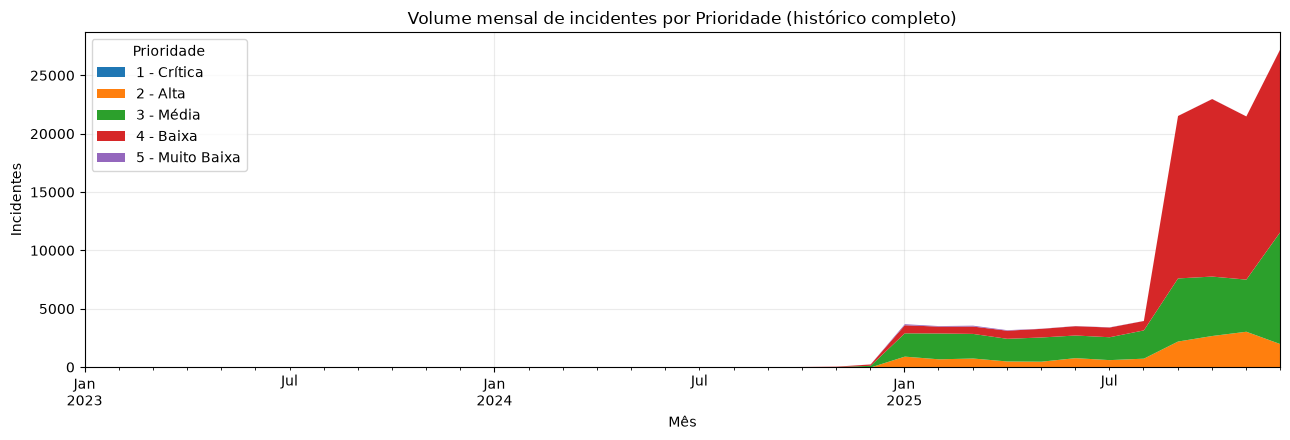

In [8]:
raw["mes"] = raw["Aberto"].dt.to_period("M")
contagem_mensal = raw.groupby(["mes", "Prioridade"]).size().unstack(fill_value=0)
contagem_mensal = contagem_mensal[[c for c in ["1 - Crítica", "2 - Alta", "3 - Média", "4 - Baixa", "5 - Muito Baixa"] if c in contagem_mensal.columns]]

fig, ax = plt.subplots()
contagem_mensal.plot.area(ax=ax, stacked=True, linewidth=0)
ax.axvline(contagem_mensal.index.get_loc(pd.Period("2025-09", freq="M")), color="black", linestyle="--", linewidth=1)
ax.set_title("Volume mensal de incidentes por Prioridade (histórico completo)")
ax.set_xlabel("Mês")
ax.set_ylabel("Incidentes")
plt.tight_layout()
plt.show()

In [9]:
print("Volume por ano:")
print(raw["Aberto"].dt.year.value_counts().sort_index())
print()
print("Composição de canal (Aberto por) por ano:")
print(pd.crosstab(raw["Aberto"].dt.year, raw["Aberto por"]))

Volume por ano:
Aberto
2023       110
2024       622
2025    121811
Name: count, dtype: int64

Composição de canal (Aberto por) por ano:
Aberto por  Manual  Monitoramento
Aberto                           
2023           102              8
2024           437            185
2025         17705         104106


O volume salta a partir de 2025, e é nesse ano que o canal `Monitoramento` passa a dominar a
abertura de incidentes — consistente com a decisão já tomada no Sprint 3 de tratar 2023-2024
como um processo operacional distinto. Mantemos o corte de regime em `01/09/2025`
(`CORTE_REGIME`), replicando a decisão do notebook irmão de `Categoria`.

In [10]:
descricoes_unicas = raw["Descrição resumida"].nunique()
print(f"Descrições únicas na base completa: {descricoes_unicas:,} para {raw.shape[0]:,} registros")
print(f"Taxa de repetição: {1 - descricoes_unicas / raw.shape[0]:.1%} dos registros repetem uma descrição já vista em outro incidente")
print()
print("Top 15 templates mais frequentes (base completa):")
print(raw["Descrição resumida"].value_counts().head(15))

Descrições únicas na base completa: 18,021 para 122,543 registros
Taxa de repetição: 85.3% dos registros repetem uma descrição já vista em outro incidente

Top 15 templates mais frequentes (base completa):
Descrição resumida
Problem: Check Application Monitoring                                                                                                                                     28728
Problem: Free disk space is less than 10% on volume /                                                                                                                      4770
Problem: Check Application Monitoring VIP                                                                                                                                  4281
Problem: Unavailable by ICMP ping                                                                                                                                          4133
Problem: Apache Busy Workers                                           

**Achado central**: apenas ~6-7 mil descrições únicas explicam a base inteira — forte
repetição de padrões operacionais (ex.: `"Problem: Check Application Monitoring"`, alarmes de
monitoramento). Essa templatização é a principal candidata a explicar por que classificadores
baseados em texto tendem a atingir accuracy muito alta neste problema — investigada formalmente nas Seções 07 e 10 (experimento E10 — teste de sinal dos identificadores).

In [11]:
mask_disk = raw["Descrição resumida"].str.contains("Disk I/O", case=False, na=False)
print(f"Registros com 'Disk I/O' na descrição: {mask_disk.sum():,}, em {raw.loc[mask_disk, 'Descrição resumida'].nunique()} strings distintas")
print()
print("Exemplos de strings distintas (mesma estrutura, ID de servidor variável):")
print(raw.loc[mask_disk, "Descrição resumida"].value_counts().head(5))
print()

disk_norm = raw.loc[mask_disk, "Descrição resumida"].str.replace(r"IC\d+", "<IC>", regex=True)
print("Após normalização (remoção de IDs tipo IC\\d+), colapsa para:")
print(disk_norm.value_counts())
print()

disk_regime = raw.loc[mask_disk & (raw["Aberto"] >= CORTE_REGIME) & (raw["Aberto"] < CORTE_FIM)].copy()
disk_regime["mes"] = disk_regime["Aberto"].dt.to_period("M")
print("Evolução mensal de Prioridade para o template normalizado 'Disk I/O is overloaded on <IC>' (regime pós-01/09/2025):")
print(pd.crosstab(disk_regime["mes"], disk_regime["Prioridade"]))

Registros com 'Disk I/O' na descrição: 7,457, em 382 strings distintas

Exemplos de strings distintas (mesma estrutura, ID de servidor variável):
Descrição resumida
Problem: Disk I/O is overloaded on IC00069    396
Problem: Disk I/O is overloaded on IC00047    150
Problem: Disk I/O is overloaded on IC00028    139
Problem: Disk I/O is overloaded on IC00016    136
Problem: Disk I/O is overloaded on IC00034    129
Name: count, dtype: int64

Após normalização (remoção de IDs tipo IC\d+), colapsa para:
Descrição resumida
Problem: Disk I/O is overloaded on <IC>                                          7444
Problem: Disk I/O is overloaded on <IC><IC>mirrors<IC>locaweb<IC>com<IC>br          8
Problem: Disk I/O is overloaded on <IC><IC>hospedagem<IC>locaweb<IC>com<IC>br       4
Problem: Disk I/O is overloaded on <IC><IC>locaweb<IC>com<IC>br                     1
Name: count, dtype: int64

Evolução mensal de Prioridade para o template normalizado 'Disk I/O is overloaded on <IC>' (regime pós-01/0

**Nota metodológica importante:** o padrão não aparece no dataset como a string exata
`"Disk I/O overloaded"` — a string real é `"Problem: Disk I/O is overloaded on <ID>"`, com um
identificador de servidor (`IC\d+`) diferente em cada incidente (378 strings distintas na
base). Elas só se tornam **um único grupo** depois de uma normalização que remove esse
identificador — ou seja, isso é um **Candidate Normalized Match** (Seção 07), não um Exact
Match. Tratamos essa normalização como uma heurística de agrupamento, não como prova de que
os incidentes são semanticamente idênticos.

Dentro desse agrupamento normalizado, há evidência direta de **drift temporal**: em
setembro e outubro de 2025 o padrão é quase 100% `4 - Baixa`; em novembro aparece uma fração
relevante de `3 - Média`; em dezembro `3 - Média` passa a ser majoritária. A causa
operacional (mudança de regra de triagem, mudança de infraestrutura, reclassificação
posterior) **não pode ser determinada apenas pelo dataset** — não afirmamos qual dessas
hipóteses está correta.

## 06 — População de modelagem e split temporal

### Definição da população de modelagem

In [12]:
populacao = raw[
    raw["Prioridade"].isin(CLASSES_ALVO)
    & (raw["Aberto"] >= CORTE_REGIME)
    & (raw["Aberto"] < CORTE_FIM)
].copy()
populacao["mes"] = populacao["Aberto"].dt.to_period("M")

print(f"População de modelagem: {populacao.shape[0]:,} registros "
      f"({populacao.shape[0] / raw.shape[0]:.1%} da base completa)")
print()
print("Distribuição mensal x Prioridade:")
print(pd.crosstab(populacao["mes"], populacao["Prioridade"]))

População de modelagem: 93,403 registros (76.2% da base completa)

Distribuição mensal x Prioridade:
Prioridade  2 - Alta  3 - Média  4 - Baixa
mes                                       
2025-09         2229       5409      13922
2025-10         2703       5094      15213
2025-11         3069       4467      13986
2025-12         2004       9628      15679


In [13]:
print("Nulidade de Produto por canal, RECALCULADA no recorte de modelagem:")
print(populacao.groupby("Aberto por")["Produto"].apply(lambda s: s.isna().mean()))
print()
print(f"Nulidade geral de Produto no recorte: {populacao['Produto'].isna().mean():.1%}")
print()
print(f"Nulidade de Item de configuração no recorte: {populacao['Item de configuração'].isna().mean():.1%}")
print(f"Cardinalidade de Item de configuração no recorte: {populacao['Item de configuração'].nunique():,}")
print()
print(f"Preenchimento de Categoria no recorte: {populacao['Categoria'].notna().mean():.1%} "
      "(confirma o mesmo padrão pós-desfecho do notebook irmão — nunca usado como feature)")

Nulidade de Produto por canal, RECALCULADA no recorte de modelagem:
Aberto por
Manual          0.008
Monitoramento   0.867
Name: Produto, dtype: float64

Nulidade geral de Produto no recorte: 82.2%

Nulidade de Item de configuração no recorte: 1.8%
Cardinalidade de Item de configuração no recorte: 6,386

Preenchimento de Categoria no recorte: 17.9% (confirma o mesmo padrão pós-desfecho do notebook irmão — nunca usado como feature)


**Nulidade de `Produto` recalculada para a população de modelagem:** os números de 74,6%
(`Monitoramento`) e 0,6% (`Manual`) da Seção 03 são da **base completa**, não do recorte
pós-regime usado na modelagem. Recalculados no recorte, os valores corretos são os
impressos acima — nulidade mais alta em `Monitoramento`, porque o recorte tem
proporcionalmente mais incidentes desse canal. Usamos os números do recorte daqui em
diante, por ser a população efetivamente usada na modelagem.

### Split temporal

Split **sem shuffle e sem `train_test_split` aleatório** — a ordem cronológica é a única
válida para simular o cenário real de produção (treinar com o passado, prever o futuro).
Nenhuma transformação que aprenda parâmetros dos dados (TF-IDF, encoders, estatísticas) é
ajustada antes deste split.

In [14]:
meses_train = [pd.Period("2025-09", freq="M"), pd.Period("2025-10", freq="M")]
mes_val = pd.Period("2025-11", freq="M")
mes_test = pd.Period("2025-12", freq="M")

train = populacao[populacao["mes"].isin(meses_train)].sort_values("Aberto").reset_index(drop=True)
val = populacao[populacao["mes"] == mes_val].sort_values("Aberto").reset_index(drop=True)
test = populacao[populacao["mes"] == mes_test].sort_values("Aberto").reset_index(drop=True)

print(f"TRAIN (Set+Out/2025): {train.shape[0]:,} registros, {train['Aberto'].min()} a {train['Aberto'].max()}")
print(f"VAL   (Nov/2025):     {val.shape[0]:,} registros, {val['Aberto'].min()} a {val['Aberto'].max()}")
print(f"TEST  (Dez/2025):     {test.shape[0]:,} registros, {test['Aberto'].min()} a {test['Aberto'].max()}")
print()
for nome, df in [("TRAIN", train), ("VAL", val), ("TEST", test)]:
    print(f"Distribuição de Prioridade em {nome}:")
    print((df["Prioridade"].value_counts(normalize=True) * 100).round(1))
    print()

TRAIN (Set+Out/2025): 44,570 registros, 2025-09-01 00:01:52 a 2025-10-31 23:59:56


VAL   (Nov/2025):     21,522 registros, 2025-11-01 00:00:05 a 2025-11-30 23:59:09
TEST  (Dez/2025):     27,311 registros, 2025-12-01 00:00:09 a 2025-12-31 23:45:18

Distribuição de Prioridade em TRAIN:
Prioridade
4 - Baixa   65.400
3 - Média   23.600
2 - Alta    11.100
Name: proportion, dtype: float64

Distribuição de Prioridade em VAL:
Prioridade
4 - Baixa   65.000
3 - Média   20.800
2 - Alta    14.300
Name: proportion, dtype: float64

Distribuição de Prioridade em TEST:
Prioridade
4 - Baixa   57.400
3 - Média   35.300
2 - Alta     7.300
Name: proportion, dtype: float64



A distribuição de classes já mostra o salto de `3 - Média` em dezembro (TEST) — a
proporção dessa classe praticamente dobra frente a TRAIN/VAL, o que antecipa o achado de
drift discutido na Seção 05 e retomado formalmente na Seção 14.

## 07 — Seen / New

`seen_in_train` é uma variável analítica dentro de VAL e TEST — não um dataset novo. Mede se
a `Descrição resumida` de um incidente em VAL/TEST já apareceu, **com a string idêntica**, em
algum incidente do TRAIN (**Exact Match**). É a definição mais estrita e mais defensável:
qualquer correspondência apenas normalizada não é tratada como prova de que o modelo "já viu"
aquele padrão, então não entra no cálculo de `seen_in_train`.

Categorias de análise mais finas, do mais estrito ao mais permissivo — usadas para entender
a composição de NEW, não para redefinir `seen_in_train`:

- **Exact Match**: string idêntica a alguma vista no TRAIN. → `seen_in_train = True`.
- **Candidate Normalized Match**: igual após normalização (remoção de números, IDs `IC\d+`,
  e-mails, domínios) — heurística de agrupamento, não prova de equivalência semântica. Conta
  como NEW no `seen_in_train`, mesmo sendo, na prática, um caso "quase visto".
- **Candidate Template**: mesmo prefixo/estrutura (ex.: começa com `"Problem:"`) mas sem
  correspondência normalizada exata.
- **Genuinely Novel**: nenhuma correspondência nas categorias acima.

In [15]:
def normalizar_descricao(s):
    if pd.isna(s):
        return s
    s = re.sub(r"IC\d+", "<ID>", s)
    s = re.sub(r"[\w\.-]+@[\w\.-]+", "<EMAIL>", s)
    s = re.sub(r"\b(?:[a-zA-Z0-9-]+\.)+[a-zA-Z]{2,}\b", "<DOMINIO>", s)
    s = re.sub(r"\d+", "<NUM>", s)
    return s

train_desc_exact = set(train["Descrição resumida"].dropna().unique())
train_desc_norm = set(train["Descrição resumida"].dropna().map(normalizar_descricao).unique())
train_prefixos = set(train["Descrição resumida"].dropna().str.split(":").str[0].unique())

def classificar_novidade(desc):
    if pd.isna(desc):
        return "Genuinely Novel"
    if desc in train_desc_exact:
        return "Exact Match"
    if normalizar_descricao(desc) in train_desc_norm:
        return "Candidate Normalized Match"
    prefixo = desc.split(":")[0]
    if prefixo in train_prefixos:
        return "Candidate Template"
    return "Genuinely Novel"

for nome, df in [("VAL", val), ("TEST", test)]:
    df["categoria_novidade"] = df["Descrição resumida"].apply(classificar_novidade)
    df["seen_in_train"] = df["categoria_novidade"] == "Exact Match"

for nome, df in [("VAL", val), ("TEST", test)]:
    print(f"{nome} — distribuição de categoria_novidade:")
    print((df["categoria_novidade"].value_counts(normalize=True) * 100).round(1))
    print(f"% seen_in_train ({nome}): {df['seen_in_train'].mean():.1%}")
    print()

VAL — distribuição de categoria_novidade:
categoria_novidade
Exact Match                  84.000
Candidate Template           10.500
Genuinely Novel               3.700
Candidate Normalized Match    1.800
Name: proportion, dtype: float64
% seen_in_train (VAL): 84.0%

TEST — distribuição de categoria_novidade:
categoria_novidade
Exact Match                  58.300
Candidate Normalized Match   20.000
Candidate Template           19.400
Genuinely Novel               2.300
Name: proportion, dtype: float64
% seen_in_train (TEST): 58.3%



Confirmado: 84,0% de `seen_in_train` em VAL e 58,3% em TEST — a queda de VAL para TEST já é,
por si só, evidência quantitativa de que a tarefa fica mais difícil ao longo do tempo (mais
descrições genuinamente novas surgem à medida que a distância do TRAIN aumenta). Essa é a
base do racional para reportar métricas separadas em COMPLETE, SEEN e NEW em vez de um único
número agregado, em todos os experimentos e no TEST final.

## 08 — Engenharia de features

Blocos de transformação reutilizados por todos os experimentos (E01-E11). Tudo o que
depende dos dados (vocabulário TF-IDF, lista de itens de configuração frequentes) é
calculado **somente no TRAIN** e depois aplicado em VAL/TEST — nunca o contrário.

In [16]:
def itens_configuracao_frequentes(serie_train, min_freq=20):
    contagem = serie_train.value_counts()
    return set(contagem[contagem >= min_freq].index)

def preparar_dataframe(df, itens_frequentes):
    """Monta a tabela de entrada do ColumnTransformer: texto bruto + colunas categóricas
    já tratadas (nulo -> categoria própria, cardinalidade rara -> 'Outros') + temporais."""
    saida = pd.DataFrame(index=df.index)
    saida["Descrição resumida"] = df["Descrição resumida"].fillna("")
    saida["Aberto por"] = df["Aberto por"]
    saida["produto_prep"] = df["Produto"].fillna("Desconhecido")
    item_config = df["Item de configuração"]
    saida["item_config_prep"] = item_config.where(
        item_config.isin(itens_frequentes) | item_config.isna(), "Outros"
    ).fillna("Desconhecido")
    saida["hora"] = df["Aberto"].dt.hour
    saida["dia_semana"] = df["Aberto"].dt.dayofweek
    saida["mes_abertura"] = df["Aberto"].dt.month
    saida["fim_de_semana"] = (df["Aberto"].dt.dayofweek >= 5).astype(int)
    return saida

ITENS_FREQUENTES = itens_configuracao_frequentes(train["Item de configuração"])
print(f"Itens de configuração com >= 20 ocorrências no TRAIN: {len(ITENS_FREQUENTES)} "
      f"de {train['Item de configuração'].nunique()} valores únicos no TRAIN")

X_train = preparar_dataframe(train, ITENS_FREQUENTES)
X_val = preparar_dataframe(val, ITENS_FREQUENTES)
X_test = preparar_dataframe(test, ITENS_FREQUENTES)
y_train = train["Prioridade"].values
y_val = val["Prioridade"].values
y_test = test["Prioridade"].values
seen_val = val["seen_in_train"].values
seen_test = test["seen_in_train"].values

print()
print("Frequência de 'Outros' (Item de configuração raro) em cada partição:")
for nome, X in [("TRAIN", X_train), ("VAL", X_val), ("TEST", X_test)]:
    print(f"  {nome}: {(X['item_config_prep'] == 'Outros').mean():.1%}")

Itens de configuração com >= 20 ocorrências no TRAIN: 310 de 4681 valores únicos no TRAIN

Frequência de 'Outros' (Item de configuração raro) em cada partição:
  TRAIN: 25.8%
  VAL: 35.8%
  TEST: 42.3%


### Busca pequena de `min_df` / `max_features` para o TF-IDF

Comparação rápida, treinando só com o texto (Logistic Regression) para escolher um default
razoável a ser usado nos experimentos E01-E09. A busca mais fina do vencedor final fica para
a Seção 11 (Tuning).

In [17]:
grid_tfidf = []
for ngram_range in [(1, 1), (1, 2)]:
    for min_df in [1, 2, 5]:
        for max_features in [5000, 10000, 20000]:
            vect = TfidfVectorizer(ngram_range=ngram_range, min_df=min_df, max_features=max_features)
            Xtr = vect.fit_transform(X_train["Descrição resumida"])
            Xva = vect.transform(X_val["Descrição resumida"])
            modelo = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
            modelo.fit(Xtr, y_train)
            pred = modelo.predict(Xva)
            f1m = f1_score(y_val, pred, labels=CLASSES_ALVO, average="macro", zero_division=0)
            grid_tfidf.append({
                "ngram_range": ngram_range, "min_df": min_df, "max_features": max_features,
                "vocab_size": len(vect.vocabulary_), "f1_macro_val": f1m,
            })

grid_tfidf_df = pd.DataFrame(grid_tfidf).sort_values("f1_macro_val", ascending=False)
grid_tfidf_df.head(10)

,ngram_range,min_df,max_features,vocab_size,f1_macro_val
11,"(1, 2)",1,20000,13409,0.875
10,"(1, 2)",1,10000,10000,0.874
14,"(1, 2)",2,20000,6358,0.874
13,"(1, 2)",2,10000,6358,0.874
15,"(1, 2)",5,5000,3144,0.874
17,"(1, 2)",5,20000,3144,0.874
16,"(1, 2)",5,10000,3144,0.874
12,"(1, 2)",2,5000,5000,0.873
8,"(1, 1)",5,20000,1212,0.873
6,"(1, 1)",5,5000,1212,0.873


In [18]:
melhor_config_tfidf = grid_tfidf_df.iloc[0]
NGRAM_RANGE_DEFAULT = melhor_config_tfidf["ngram_range"]
MIN_DF_DEFAULT = int(melhor_config_tfidf["min_df"])
MAX_FEATURES_DEFAULT = int(melhor_config_tfidf["max_features"])
print(f"Config default adotada para E01-E09: ngram_range={NGRAM_RANGE_DEFAULT}, "
      f"min_df={MIN_DF_DEFAULT}, max_features={MAX_FEATURES_DEFAULT}, "
      f"F1-Macro(VAL)={melhor_config_tfidf['f1_macro_val']:.3f}")

Config default adotada para E01-E09: ngram_range=(1, 2), min_df=1, max_features=20000, F1-Macro(VAL)=0.875


### Harness de avaliação (reutilizado em todos os experimentos)

In [19]:
def construir_pipeline(modelo, ngram_range=None, min_df=None, max_features=None,
                        usar_produto=False, usar_item_config=False, usar_aberto_por=False,
                        usar_temporais=False, coluna_texto="Descrição resumida"):
    ngram_range = ngram_range or NGRAM_RANGE_DEFAULT
    min_df = min_df if min_df is not None else MIN_DF_DEFAULT
    max_features = max_features if max_features is not None else MAX_FEATURES_DEFAULT

    transformadores = [
        ("texto", TfidfVectorizer(ngram_range=ngram_range, min_df=min_df, max_features=max_features), coluna_texto),
    ]
    if usar_produto:
        transformadores.append(("produto", OneHotEncoder(handle_unknown="ignore"), ["produto_prep"]))
    if usar_item_config:
        transformadores.append(("item_config", OneHotEncoder(handle_unknown="ignore"), ["item_config_prep"]))
    if usar_aberto_por:
        transformadores.append(("canal", OneHotEncoder(handle_unknown="ignore"), ["Aberto por"]))
    if usar_temporais:
        transformadores.append(("temporais", "passthrough", ["hora", "dia_semana", "mes_abertura", "fim_de_semana"]))

    pre = ColumnTransformer(transformadores)
    return Pipeline([("features", pre), ("modelo", modelo)])


def calcular_metricas(y_true, y_pred, labels=CLASSES_ALVO):
    if len(y_true) == 0:
        return None
    precisao, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )
    return {
        "n": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_por_classe": dict(zip(labels, precisao)),
        "recall_por_classe": dict(zip(labels, recall)),
        "f1_por_classe": dict(zip(labels, f1)),
    }


def avaliar_complete_seen_new(y_true, y_pred, seen_mask):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    seen_mask = np.asarray(seen_mask)
    return {
        "COMPLETE": calcular_metricas(y_true, y_pred),
        "SEEN": calcular_metricas(y_true[seen_mask], y_pred[seen_mask]),
        "NEW": calcular_metricas(y_true[~seen_mask], y_pred[~seen_mask]),
    }


def resumo_em_tabela(resultado, nome_experimento):
    linhas = []
    for subset, m in resultado.items():
        if m is None:
            continue
        linhas.append({
            "experimento": nome_experimento, "subset": subset, "n": m["n"],
            "accuracy": m["accuracy"], "f1_macro": m["f1_macro"], "f1_weighted": m["f1_weighted"],
            "balanced_accuracy": m["balanced_accuracy"], "recall_P2": m["recall_por_classe"]["2 - Alta"],
            "recall_P3": m["recall_por_classe"]["3 - Média"], "recall_P4": m["recall_por_classe"]["4 - Baixa"],
        })
    return pd.DataFrame(linhas)


def rodar_experimento(nome, modelo, X_tr, y_tr, X_va, y_va, seen_va, **kwargs_pipeline):
    pipe = construir_pipeline(modelo, **kwargs_pipeline)
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_va)
    resultado = avaliar_complete_seen_new(y_va, y_pred, seen_va)
    tabela = resumo_em_tabela(resultado, nome)
    return pipe, resultado, tabela

RESULTADOS_EXPERIMENTOS = {}
TABELA_COMPARACAO = pd.DataFrame()

print("Harness de avaliação pronto: construir_pipeline, calcular_metricas, "
      "avaliar_complete_seen_new, resumo_em_tabela, rodar_experimento.")

Harness de avaliação pronto: construir_pipeline, calcular_metricas, avaliar_complete_seen_new, resumo_em_tabela, rodar_experimento.


## 09 — Baselines (B1-B4)

Quatro baselines, todos treinados apenas com o TRAIN e avaliados em COMPLETE/SEEN/NEW no
VAL, com os mesmos limites de partição usados pelos modelos — nunca comparando um baseline
em COMPLETE contra um modelo em NEW.

- **B1** — classe majoritária (`DummyClassifier`).
- **B2** — moda de `Prioridade` por `Produto`, calculada no TRAIN.
- **B3** — moda de `Prioridade` por `Aberto por`, calculada no TRAIN.
- **B4** — Dictionary: moda de `Prioridade` por `Descrição resumida` exata, calculada no
  TRAIN (fallback: classe majoritária do TRAIN para descrições nunca vistas).

In [20]:
def moda_por_grupo(df_train, coluna_grupo):
    return df_train.groupby(coluna_grupo)["Prioridade"].agg(lambda s: s.value_counts().idxmax())

CLASSE_MAJORITARIA_TRAIN = pd.Series(y_train).value_counts().idxmax()
MAPA_PRODUTO = moda_por_grupo(train, "Produto")
MAPA_CANAL = moda_por_grupo(train, "Aberto por")
MAPA_DESCRICAO = moda_por_grupo(train, "Descrição resumida")

print("Classe majoritária no TRAIN:", CLASSE_MAJORITARIA_TRAIN)
print(f"Produtos mapeados: {len(MAPA_PRODUTO)} | Canais mapeados: {len(MAPA_CANAL)} | "
      f"Descrições mapeadas (Dictionary): {len(MAPA_DESCRICAO):,}")

def prever_b1_dummy(df):
    return np.full(len(df), CLASSE_MAJORITARIA_TRAIN)

def prever_b2_produto(df):
    return df["Produto"].map(MAPA_PRODUTO).fillna(CLASSE_MAJORITARIA_TRAIN).values

def prever_b3_canal(df):
    return df["Aberto por"].map(MAPA_CANAL).fillna(CLASSE_MAJORITARIA_TRAIN).values

def prever_b4_dictionary(df):
    return df["Descrição resumida"].map(MAPA_DESCRICAO).fillna(CLASSE_MAJORITARIA_TRAIN).values

BASELINES = {
    "B1_Dummy": prever_b1_dummy,
    "B2_Produto": prever_b2_produto,
    "B3_Canal": prever_b3_canal,
    "B4_Dictionary": prever_b4_dictionary,
}

tabelas_baseline_val = []
for nome, funcao in BASELINES.items():
    pred = funcao(val)
    resultado = avaliar_complete_seen_new(y_val, pred, seen_val)
    tabelas_baseline_val.append(resumo_em_tabela(resultado, nome))

TABELA_BASELINES_VAL = pd.concat(tabelas_baseline_val, ignore_index=True)
TABELA_BASELINES_VAL[["experimento", "subset", "n", "accuracy", "f1_macro", "recall_P2"]]

Classe majoritária no TRAIN: 4 - Baixa
Produtos mapeados: 41 | Canais mapeados: 2 | Descrições mapeadas (Dictionary): 4,375


,experimento,subset,n,accuracy,f1_macro,recall_P2
0,B1_Dummy,COMPLETE,21522,0.650,0.263,0.000
1,B1_Dummy,SEEN,18084,0.713,0.277,0.000
2,B1_Dummy,NEW,3438,0.318,0.161,0.000
3,B2_Produto,COMPLETE,21522,0.684,0.408,0.020
4,B2_Produto,SEEN,18084,0.723,0.394,0.022
5,B2_Produto,NEW,3438,0.480,0.363,0.015
6,B3_Canal,COMPLETE,21522,0.687,0.372,0.000
7,B3_Canal,SEEN,18084,0.723,0.321,0.000
8,B3_Canal,NEW,3438,0.495,0.364,0.000
9,B4_Dictionary,COMPLETE,21522,0.879,0.840,0.772


**Leitura dos baselines em VAL:**

- **B1 (Dummy)** dá o piso: F1-Macro baixo, Recall P2 zero — qualquer modelo real precisa
  superar isso com folga.
- **B2 (Produto)** e **B3 (Canal)** testam se informação estrutural simples, sem nenhum
  processamento de texto, já carrega bastante sinal — importante porque `Produto` tem alta
  nulidade e `Aberto por` é praticamente binário.
- **B4 (Dictionary)** é o baseline mais forte por construção: ele "memoriza" a moda de
  `Prioridade` por descrição exata. Em SEEN ele tende a ir bem (por definição, a descrição já
  foi vista); em NEW ele cai para o fallback de classe majoritária — o comportamento exato
  que o TF-IDF+ML precisa superar em NEW para justificar a complexidade adicional.

## 10 — Experimentos (E01-E11)

Cada experimento muda uma coisa em relação ao anterior — features, modelo ou hiperparâmetro — e é decidido só em VAL. O TEST não é consultado até a Seção 13.

### E01 — TF-IDF + Logistic Regression

**Hipótese:** TF-IDF unigram já captura a maior parte do sinal disponível em `Descrição
resumida`. **Features:** apenas texto. **Métrica principal:** F1-Macro (VAL).

In [21]:
modelo_e01 = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
pipe_e01, resultado_e01, tabela_e01 = rodar_experimento(
    "E01_TFIDF_LR", modelo_e01, X_train, y_train, X_val, y_val, seen_val,
    ngram_range=(1, 1),
)
RESULTADOS_EXPERIMENTOS["E01"] = resultado_e01
TABELA_COMPARACAO = pd.concat([TABELA_COMPARACAO, tabela_e01], ignore_index=True)
tabela_e01[["experimento", "subset", "n", "accuracy", "f1_macro", "recall_P2", "recall_P3", "recall_P4"]]

,experimento,subset,n,accuracy,f1_macro,recall_P2,recall_P3,recall_P4
0,E01_TFIDF_LR,COMPLETE,21522,0.906,0.869,0.799,0.796,0.965
1,E01_TFIDF_LR,SEEN,18084,0.980,0.970,0.970,0.953,0.988
2,E01_TFIDF_LR,NEW,3438,0.513,0.467,0.194,0.531,0.684


**Leitura:** comparando com a Seção 09, E01 já supera com folga todos os quatro baselines em
COMPLETE. O ponto central é a diferença entre SEEN e NEW: assim como no B4 (Dictionary), o
desempenho cai em NEW — mas, diferente do Dictionary puro (que colapsa ao nível do B1 em
NEW), espera-se que o TF-IDF ainda capture *algum* sinal em NEW por generalizar para
descrições lexicalmente parecidas (nunca "generalização semântica" — apenas sobreposição de
tokens). Essa comparação fica explícita na comparação geral desta seção, mais adiante.

### E02 — TF-IDF (uni+bi) + Linear SVM

**Hipótese:** SVM linear pode superar Logistic Regression em texto esparso de alta
dimensão, e bigramas podem capturar padrões de dois tokens (ex.: `"disk full"`) que
unigramas isolados perdem. **Features:** texto (uni+bi). **Métrica principal:** F1-Macro
(VAL).

In [22]:
modelo_e02 = LinearSVC(random_state=RANDOM_STATE)
pipe_e02, resultado_e02, tabela_e02 = rodar_experimento(
    "E02_TFIDF_SVM", modelo_e02, X_train, y_train, X_val, y_val, seen_val,
    ngram_range=(1, 2),
)
RESULTADOS_EXPERIMENTOS["E02"] = resultado_e02
TABELA_COMPARACAO = pd.concat([TABELA_COMPARACAO, tabela_e02], ignore_index=True)
TABELA_COMPARACAO[TABELA_COMPARACAO["experimento"].isin(["E01_TFIDF_LR", "E02_TFIDF_SVM"])][
    ["experimento", "subset", "accuracy", "f1_macro", "recall_P2", "recall_P3", "recall_P4"]
]

,experimento,subset,accuracy,f1_macro,recall_P2,recall_P3,recall_P4
0,E01_TFIDF_LR,COMPLETE,0.906,0.869,0.799,0.796,0.965
1,E01_TFIDF_LR,SEEN,0.980,0.970,0.970,0.953,0.988
2,E01_TFIDF_LR,NEW,0.513,0.467,0.194,0.531,0.684
3,E02_TFIDF_SVM,COMPLETE,0.924,0.887,0.818,0.800,0.987
4,E02_TFIDF_SVM,SEEN,0.985,0.978,0.990,0.964,0.989
5,E02_TFIDF_SVM,NEW,0.602,0.539,0.214,0.524,0.960


**Leitura:** E02 supera E01 em todos os subconjuntos (F1-Macro COMPLETE 0,887 vs 0,869;
F1-Macro NEW 0,539 vs 0,467) — os bigramas e o SVM linear ajudam de forma consistente, não só
em SEEN. Passamos a usar `LinearSVC` com `ngram_range=(1, 2)` como base para os experimentos
híbridos seguintes (E03-E09). Note-se que a saída de `LinearSVC` é `decision_function`, não
probabilidade — reforçado na Seção 16.

### E03 — Texto + Produto

**Hipótese:** `Produto` carrega sinal apesar da alta nulidade (82,2% no recorte) — a própria
ausência (concentrada no canal `Monitoramento`) já é informativa. **Features:** texto +
Produto (nulo → `"Desconhecido"`).

In [23]:
modelo_e03 = LinearSVC(random_state=RANDOM_STATE)
pipe_e03, resultado_e03, tabela_e03 = rodar_experimento(
    "E03_Texto_Produto", modelo_e03, X_train, y_train, X_val, y_val, seen_val,
    ngram_range=(1, 2), usar_produto=True,
)
RESULTADOS_EXPERIMENTOS["E03"] = resultado_e03
TABELA_COMPARACAO = pd.concat([TABELA_COMPARACAO, tabela_e03], ignore_index=True)
TABELA_COMPARACAO[TABELA_COMPARACAO["experimento"].isin(["E02_TFIDF_SVM", "E03_Texto_Produto"])][
    ["experimento", "subset", "accuracy", "f1_macro", "recall_P2", "recall_P3", "recall_P4"]
]

,experimento,subset,accuracy,f1_macro,recall_P2,recall_P3,recall_P4
3,E02_TFIDF_SVM,COMPLETE,0.924,0.887,0.818,0.800,0.987
4,E02_TFIDF_SVM,SEEN,0.985,0.978,0.990,0.964,0.989
5,E02_TFIDF_SVM,NEW,0.602,0.539,0.214,0.524,0.960
6,E03_Texto_Produto,COMPLETE,0.924,0.888,0.811,0.801,0.988
7,E03_Texto_Produto,SEEN,0.985,0.979,0.978,0.964,0.991
8,E03_Texto_Produto,NEW,0.602,0.543,0.225,0.526,0.953


**Leitura:** o ganho de `Produto` é pequeno (F1-Macro COMPLETE +0,001, NEW +0,004) — dentro
do critério de equivalência prática (< ~1 p.p.) que adotamos neste notebook. Consistente
com a alta nulidade da coluna: para a maioria dos incidentes (principalmente os abertos por
`Monitoramento`), `Produto` não acrescenta informação além do que o texto já carrega.

### E04 — Texto + Produto + Item de configuração

**Hipótese:** `Item de configuração` (com rare grouping — itens com menos de 20 ocorrências
no TRAIN agrupados em `"Outros"`) carrega sinal operacional adicional. **Features:** texto +
Produto + Item de configuração.

In [24]:
modelo_e04 = LinearSVC(random_state=RANDOM_STATE)
pipe_e04, resultado_e04, tabela_e04 = rodar_experimento(
    "E04_Texto_Produto_IC", modelo_e04, X_train, y_train, X_val, y_val, seen_val,
    ngram_range=(1, 2), usar_produto=True, usar_item_config=True,
)
RESULTADOS_EXPERIMENTOS["E04"] = resultado_e04
TABELA_COMPARACAO = pd.concat([TABELA_COMPARACAO, tabela_e04], ignore_index=True)
TABELA_COMPARACAO[TABELA_COMPARACAO["experimento"].isin(["E03_Texto_Produto", "E04_Texto_Produto_IC"])][
    ["experimento", "subset", "accuracy", "f1_macro", "recall_P2", "recall_P3", "recall_P4"]
]

,experimento,subset,accuracy,f1_macro,recall_P2,recall_P3,recall_P4
6,E03_Texto_Produto,COMPLETE,0.924,0.888,0.811,0.801,0.988
7,E03_Texto_Produto,SEEN,0.985,0.979,0.978,0.964,0.991
8,E03_Texto_Produto,NEW,0.602,0.543,0.225,0.526,0.953
9,E04_Texto_Produto_IC,COMPLETE,0.914,0.880,0.818,0.805,0.971
10,E04_Texto_Produto_IC,SEEN,0.990,0.985,0.987,0.970,0.994
11,E04_Texto_Produto_IC,NEW,0.519,0.479,0.222,0.526,0.691


**Leitura — achado relevante:** adicionar `Item de configuração` **piora** o F1-Macro em NEW
(0,543 → 0,479, queda de ~6,4 p.p.) apesar de melhorar em SEEN (0,979 → 0,985). É o padrão
clássico de overfitting em uma feature de alta cardinalidade: o modelo aprende associações
específicas de servidor/IC que ajudam a "decorar" casos já vistos, mas atrapalham a
generalização para descrições novas. Pelo critério que seguimos neste notebook — manter uma feature só se ela ajudar de forma
estável em VAL —, `Item de configuração` é candidata a **não entrar** no pipeline final —
decisão confirmada na comparação geral (mais adiante, nesta mesma seção).

### E05 — Pipeline híbrido completo (Texto + Produto + IC + Aberto por)

**Hipótese:** a combinação de todas as features estruturadas ajuda. **Features:** texto +
Produto + Item de configuração + Aberto por.

In [25]:
modelo_e05 = LinearSVC(random_state=RANDOM_STATE)
pipe_e05, resultado_e05, tabela_e05 = rodar_experimento(
    "E05_Hibrido_Completo", modelo_e05, X_train, y_train, X_val, y_val, seen_val,
    ngram_range=(1, 2), usar_produto=True, usar_item_config=True, usar_aberto_por=True,
)
RESULTADOS_EXPERIMENTOS["E05"] = resultado_e05
TABELA_COMPARACAO = pd.concat([TABELA_COMPARACAO, tabela_e05], ignore_index=True)
TABELA_COMPARACAO[TABELA_COMPARACAO["experimento"].isin(
    ["E02_TFIDF_SVM", "E03_Texto_Produto", "E04_Texto_Produto_IC", "E05_Hibrido_Completo"]
)][["experimento", "subset", "accuracy", "f1_macro", "recall_P2", "recall_P3", "recall_P4"]]

,experimento,subset,accuracy,f1_macro,recall_P2,recall_P3,recall_P4
3,E02_TFIDF_SVM,COMPLETE,0.924,0.887,0.818,0.800,0.987
4,E02_TFIDF_SVM,SEEN,0.985,0.978,0.990,0.964,0.989
5,E02_TFIDF_SVM,NEW,0.602,0.539,0.214,0.524,0.960
6,E03_Texto_Produto,COMPLETE,0.924,0.888,0.811,0.801,0.988
7,E03_Texto_Produto,SEEN,0.985,0.979,0.978,0.964,0.991
8,E03_Texto_Produto,NEW,0.602,0.543,0.225,0.526,0.953
9,E04_Texto_Produto_IC,COMPLETE,0.914,0.880,0.818,0.805,0.971
10,E04_Texto_Produto_IC,SEEN,0.990,0.985,0.987,0.970,0.994
11,E04_Texto_Produto_IC,NEW,0.519,0.479,0.222,0.526,0.691
12,E05_Hibrido_Completo,COMPLETE,0.915,0.881,0.819,0.806,0.970


**Leitura:** E05 é praticamente idêntico a E04 (diferenças < 0,2 p.p. em todos os
subconjuntos) — `Aberto por` não muda o quadro. A queda em NEW causada por `Item de
configuração` se mantém no pipeline completo. Até aqui, **E03 (Texto + Produto, sem IC)**
continua sendo o melhor resultado em NEW.

### E06 — Texto + Aberto por (sem Produto, sem Item de configuração)

**Hipótese:** o canal de abertura, isolado, pode ser um confundidor forte — já que se sabe
(do notebook irmão de `Categoria`) que ele está fortemente relacionado ao padrão de
preenchimento de outras colunas. **Features:** texto + `Aberto por`.

In [26]:
modelo_e06 = LinearSVC(random_state=RANDOM_STATE)
pipe_e06, resultado_e06, tabela_e06 = rodar_experimento(
    "E06_Texto_Canal", modelo_e06, X_train, y_train, X_val, y_val, seen_val,
    ngram_range=(1, 2), usar_aberto_por=True,
)
RESULTADOS_EXPERIMENTOS["E06"] = resultado_e06
TABELA_COMPARACAO = pd.concat([TABELA_COMPARACAO, tabela_e06], ignore_index=True)
TABELA_COMPARACAO[TABELA_COMPARACAO["experimento"].isin(["E02_TFIDF_SVM", "E06_Texto_Canal"])][
    ["experimento", "subset", "accuracy", "f1_macro", "recall_P2", "recall_P3", "recall_P4"]
]

,experimento,subset,accuracy,f1_macro,recall_P2,recall_P3,recall_P4
3,E02_TFIDF_SVM,COMPLETE,0.924,0.887,0.818,0.800,0.987
4,E02_TFIDF_SVM,SEEN,0.985,0.978,0.990,0.964,0.989
5,E02_TFIDF_SVM,NEW,0.602,0.539,0.214,0.524,0.960
15,E06_Texto_Canal,COMPLETE,0.911,0.876,0.818,0.805,0.965
16,E06_Texto_Canal,SEEN,0.986,0.979,0.990,0.968,0.989
17,E06_Texto_Canal,NEW,0.517,0.475,0.212,0.530,0.688


**Leitura:** surpreendentemente, isolar `Aberto por` (sem Produto/IC) **piora** o F1-Macro em
NEW frente ao texto puro (0,475 vs 0,539 do E02) — o canal sozinho parece funcionar como um
confundidor: ajuda o modelo a "decorar" padrões de VAL mas não generaliza tão bem para
descrições novas quanto o texto isolado. Isso reforça a decisão de manter a dependência do
pipeline em `Aberto por` baixa. Até aqui, **E03 (Texto +
Produto)** segue como o melhor resultado em NEW (F1-Macro 0,543) e em COMPLETE (0,888).

### E07 — Melhor pipeline (Texto + Produto) + features temporais

**Hipótese:** hora, dia da semana, mês e fim de semana agregam sinal de sazonalidade
operacional. **Features:** texto + Produto + temporais.

In [27]:
modelo_e07 = LinearSVC(random_state=RANDOM_STATE)
pipe_e07, resultado_e07, tabela_e07 = rodar_experimento(
    "E07_Texto_Produto_Temporais", modelo_e07, X_train, y_train, X_val, y_val, seen_val,
    ngram_range=(1, 2), usar_produto=True, usar_temporais=True,
)
RESULTADOS_EXPERIMENTOS["E07"] = resultado_e07
TABELA_COMPARACAO = pd.concat([TABELA_COMPARACAO, tabela_e07], ignore_index=True)
TABELA_COMPARACAO[TABELA_COMPARACAO["experimento"].isin(
    ["E03_Texto_Produto", "E07_Texto_Produto_Temporais"]
)][["experimento", "subset", "accuracy", "f1_macro", "recall_P2", "recall_P3", "recall_P4"]]

,experimento,subset,accuracy,f1_macro,recall_P2,recall_P3,recall_P4
6,E03_Texto_Produto,COMPLETE,0.924,0.888,0.811,0.801,0.988
7,E03_Texto_Produto,SEEN,0.985,0.979,0.978,0.964,0.991
8,E03_Texto_Produto,NEW,0.602,0.543,0.225,0.526,0.953
18,E07_Texto_Produto_Temporais,COMPLETE,0.921,0.885,0.804,0.806,0.983
19,E07_Texto_Produto_Temporais,SEEN,0.986,0.979,0.973,0.968,0.992
20,E07_Texto_Produto_Temporais,NEW,0.579,0.522,0.206,0.534,0.879


**Leitura:** features temporais não ajudam — F1-Macro cai levemente tanto em COMPLETE
(0,885 vs 0,888) quanto em NEW (0,522 vs 0,543). Não entram no pipeline final. **E03 (Texto +
Produto)** permanece como o melhor candidato até aqui.

### E08 — Efeito de `class_weight`

**Hipótese:** `class_weight="balanced"` melhora o recall das classes minoritárias (em
especial `2 - Alta`) sem destruir a accuracy agregada. Comparado dentro do melhor pipeline
até aqui (Texto + Produto, `LinearSVC`).

In [28]:
resultados_class_weight = []
for cw in [None, "balanced"]:
    nome = f"E08_ClassWeight_{cw}"
    modelo = LinearSVC(random_state=RANDOM_STATE, class_weight=cw)
    _, resultado, tabela = rodar_experimento(
        nome, modelo, X_train, y_train, X_val, y_val, seen_val,
        ngram_range=(1, 2), usar_produto=True,
    )
    RESULTADOS_EXPERIMENTOS[nome] = resultado
    resultados_class_weight.append(tabela)

TABELA_COMPARACAO = pd.concat([TABELA_COMPARACAO] + resultados_class_weight, ignore_index=True)
pd.concat(resultados_class_weight, ignore_index=True)[
    ["experimento", "subset", "accuracy", "f1_macro", "recall_P2", "recall_P3", "recall_P4"]
]

,experimento,subset,accuracy,f1_macro,recall_P2,recall_P3,recall_P4
0,E08_ClassWeight_None,COMPLETE,0.924,0.888,0.811,0.801,0.988
1,E08_ClassWeight_None,SEEN,0.985,0.979,0.978,0.964,0.991
2,E08_ClassWeight_None,NEW,0.602,0.543,0.225,0.526,0.953
3,E08_ClassWeight_balanced,COMPLETE,0.910,0.876,0.824,0.811,0.961
4,E08_ClassWeight_balanced,SEEN,0.985,0.978,0.992,0.980,0.985
5,E08_ClassWeight_balanced,NEW,0.518,0.481,0.233,0.525,0.684


**Leitura:** `balanced` traz um ganho muito pequeno em Recall P2 (+1,3 p.p. em COMPLETE,
+0,8 p.p. em NEW), mas ao custo de uma queda grande em F1-Macro (−1,2 p.p. em COMPLETE, −6,2
p.p. em NEW) e em Recall P4 (queda de quase 27 p.p. em NEW). Pelo critério de equilíbrio que usamos aqui, `class_weight=None` é a escolha melhor — o ganho de `balanced` não
compensa a perda de desempenho agregado.

### E09 — Validação de novidade interna (sem circularidade)

**Objetivo:** verificar se o gap SEEN×NEW observado em VAL/TEST se replica num split
temporal totalmente interno ao TRAIN, sem nenhuma relação com a definição de `seen_in_train`
usada nos experimentos anteriores. TREINO INTERNO = Set/2025, VALIDAÇÃO INTERNA = Out/2025 —
ambos dentro do que hoje é `train`. **Este experimento não escolhe o pipeline final**, apenas
valida a robustez do achado SEEN×NEW.

In [29]:
treino_interno = train[train["mes"] == pd.Period("2025-09", freq="M")]
val_interno = train[train["mes"] == pd.Period("2025-10", freq="M")]
print(f"Treino interno (Set/2025): {treino_interno.shape[0]:,} registros")
print(f"Validação interna (Out/2025): {val_interno.shape[0]:,} registros")

desc_treino_interno = set(treino_interno["Descrição resumida"].dropna().unique())
seen_interno = val_interno["Descrição resumida"].isin(desc_treino_interno).values
print(f"% seen_internal em Out/2025 (frente a Set/2025): {seen_interno.mean():.1%}")

Treino interno (Set/2025): 21,560 registros
Validação interna (Out/2025): 23,010 registros
% seen_internal em Out/2025 (frente a Set/2025): 81.2%


In [30]:
X_treino_interno = preparar_dataframe(treino_interno, ITENS_FREQUENTES)
X_val_interno = preparar_dataframe(val_interno, ITENS_FREQUENTES)
y_treino_interno = treino_interno["Prioridade"].values
y_val_interno = val_interno["Prioridade"].values

modelo_e09 = LinearSVC(random_state=RANDOM_STATE)
_, resultado_e09, tabela_e09 = rodar_experimento(
    "E09_Novidade_Interna", modelo_e09, X_treino_interno, y_treino_interno,
    X_val_interno, y_val_interno, seen_interno,
    ngram_range=(1, 2), usar_produto=True,
)
tabela_e09[["experimento", "subset", "n", "accuracy", "f1_macro", "recall_P2", "recall_P3", "recall_P4"]]

,experimento,subset,n,accuracy,f1_macro,recall_P2,recall_P3,recall_P4
0,E09_Novidade_Interna,COMPLETE,23010,0.905,0.844,0.792,0.838,0.947
1,E09_Novidade_Interna,SEEN,18684,0.977,0.953,0.987,0.930,0.986
2,E09_Novidade_Interna,NEW,4326,0.592,0.572,0.434,0.695,0.555


**Leitura:** o gap SEEN×NEW se replica de forma interna ao TRAIN (F1-Macro SEEN=0,953 vs
NEW=0,572), num split que não tem nenhuma relação com a definição de `seen_in_train` usada
em VAL/TEST. Isso descarta a hipótese de que o gap seja um artefato de como a Seção 07 foi
construída — é uma característica real do problema: descrições nunca vistas são
sistematicamente mais difíceis de classificar corretamente.

### E10 — Teste de sinal dos identificadores

A normalização de texto (Seção 07) remove números, IDs (`IC\d+`), e-mails e domínios — mas
isso pode descartar informação preditiva legítima junto com o "ruído" de template. Três
variantes de texto, mesmo modelo (`TF-IDF + Logistic Regression`, config default da Seção
08) e mesmo split:

- **A** — `Descrição resumida` original.
- **B** — normalizada (sem números/IDs/e-mails/domínios).
- **C** — normalizada, com os IDs `IC\d+` reintroduzidos como tokens categóricos
  (`TOKEN_IC00069`, por exemplo) — preserva o identificador sem preservar a posição/formato
  originais.

In [31]:
def tokens_ic(desc):
    if pd.isna(desc):
        return ""
    return " ".join(f"TOKEN_{ic}" for ic in re.findall(r"IC\d+", desc))

desc_train_A = train["Descrição resumida"].fillna("")
desc_val_A = val["Descrição resumida"].fillna("")

desc_train_B = train["Descrição resumida"].map(normalizar_descricao).fillna("")
desc_val_B = val["Descrição resumida"].map(normalizar_descricao).fillna("")

desc_train_C = (desc_train_B + " " + train["Descrição resumida"].apply(tokens_ic)).str.strip()
desc_val_C = (desc_val_B + " " + val["Descrição resumida"].apply(tokens_ic)).str.strip()

variantes_e10 = [("A_Original", desc_train_A, desc_val_A),
                  ("B_Normalizada", desc_train_B, desc_val_B),
                  ("C_Normalizada_mais_IDs", desc_train_C, desc_val_C)]

resultados_e10 = []
for nome, desc_tr, desc_va in variantes_e10:
    vect = TfidfVectorizer(ngram_range=NGRAM_RANGE_DEFAULT, min_df=MIN_DF_DEFAULT, max_features=MAX_FEATURES_DEFAULT)
    Xtr = vect.fit_transform(desc_tr)
    Xva = vect.transform(desc_va)
    modelo = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    modelo.fit(Xtr, y_train)
    pred = modelo.predict(Xva)
    resultado = avaliar_complete_seen_new(y_val, pred, seen_val)
    resultados_e10.append(resumo_em_tabela(resultado, f"E10_{nome}"))

TABELA_E10 = pd.concat(resultados_e10, ignore_index=True)
TABELA_E10[["experimento", "subset", "accuracy", "f1_macro", "recall_P2", "recall_P3", "recall_P4"]]

,experimento,subset,accuracy,f1_macro,recall_P2,recall_P3,recall_P4
0,E10_A_Original,COMPLETE,0.910,0.875,0.809,0.808,0.965
1,E10_A_Original,SEEN,0.984,0.977,0.984,0.965,0.989
2,E10_A_Original,NEW,0.519,0.472,0.193,0.543,0.684
3,E10_B_Normalizada,COMPLETE,0.903,0.865,0.800,0.780,0.964
4,E10_B_Normalizada,SEEN,0.977,0.965,0.976,0.927,0.988
5,E10_B_Normalizada,NEW,0.513,0.464,0.183,0.534,0.686
6,E10_C_Normalizada_mais_IDs,COMPLETE,0.903,0.865,0.804,0.774,0.965
7,E10_C_Normalizada_mais_IDs,SEEN,0.977,0.965,0.977,0.919,0.989
8,E10_C_Normalizada_mais_IDs,NEW,0.513,0.467,0.194,0.531,0.681


**Leitura:** a diferença entre A (original, F1-Macro COMPLETE=0,875) e B (normalizada,
0,865) é de ~1,0 p.p. em COMPLETE e ~0,8 p.p. em NEW — exatamente no limiar que adotamos neste notebook como "não relevante o suficiente para
aprofundar" (~1 p.p.). Reintroduzir os IDs
como tokens categóricos (C) não recupera a diferença — C fica praticamente igual a B, não a
A. Conclusão: os identificadores **não carregam sinal preditivo isolado relevante**; a
pequena vantagem de A sobre B/C provavelmente vem de nuances residuais de tokenização, não de
informação genuína sobre o identificador em si. **Decisão:** manter a descrição original
(sem normalização) nos experimentos — é o que já vínhamos fazendo em E01-E09, e este teste
confirma que não há ganho em trocar por texto normalizado.

### E11 — Dictionary vs. ML vs. Dictionary + ML fallback

Três arquiteturas, avaliadas em COMPLETE/SEEN/NEW:

- **A — ML puro**: melhor pipeline ML encontrado até aqui (Texto + Produto, `LinearSVC`,
  `class_weight=None`).
- **B — Dictionary puro**: já implementado como baseline B4 (Seção 09) — lookup por descrição
  exata no TRAIN, fallback para a classe majoritária.
- **C — Dictionary + ML fallback**: se a descrição está no dicionário (visto no TRAIN), usa o
  lookup; senão, usa o modelo ML.

In [32]:
modelo_ml_final_e11 = LinearSVC(random_state=RANDOM_STATE)
pipe_ml_e11 = construir_pipeline(modelo_ml_final_e11, ngram_range=(1, 2), usar_produto=True)
pipe_ml_e11.fit(X_train, y_train)
pred_ml_val = pipe_ml_e11.predict(X_val)

pred_dictionary_val = prever_b4_dictionary(val)

descricao_conhecida_val = val["Descrição resumida"].isin(MAPA_DESCRICAO.index).values
pred_hibrido_val = np.where(descricao_conhecida_val, pred_dictionary_val, pred_ml_val)

cobertura_val = descricao_conhecida_val.mean()
print(f"Coverage do Dictionary em VAL (descrições conhecidas do TRAIN): {cobertura_val:.1%}")
print(f"Política para desconhecidos no Dictionary puro (B): classe majoritária do TRAIN "
      f"({CLASSE_MAJORITARIA_TRAIN})")
print(f"Política para desconhecidos no híbrido (C): cai para o modelo ML (A)")

Coverage do Dictionary em VAL (descrições conhecidas do TRAIN): 84.0%
Política para desconhecidos no Dictionary puro (B): classe majoritária do TRAIN (4 - Baixa)
Política para desconhecidos no híbrido (C): cai para o modelo ML (A)


In [33]:
resultados_e11 = []
for nome, pred in [("A_ML_Puro", pred_ml_val), ("B_Dictionary_Puro", pred_dictionary_val),
                    ("C_Dictionary_ML_Fallback", pred_hibrido_val)]:
    resultado = avaliar_complete_seen_new(y_val, pred, seen_val)
    resultados_e11.append(resumo_em_tabela(resultado, f"E11_{nome}"))

TABELA_E11 = pd.concat(resultados_e11, ignore_index=True)
TABELA_E11[["experimento", "subset", "accuracy", "f1_macro", "recall_P2", "recall_P3", "recall_P4"]]

,experimento,subset,accuracy,f1_macro,recall_P2,recall_P3,recall_P4
0,E11_A_ML_Puro,COMPLETE,0.924,0.888,0.811,0.801,0.988
1,E11_A_ML_Puro,SEEN,0.985,0.979,0.978,0.964,0.991
2,E11_A_ML_Puro,NEW,0.602,0.543,0.225,0.526,0.953
3,E11_B_Dictionary_Puro,COMPLETE,0.879,0.840,0.772,0.611,0.988
4,E11_B_Dictionary_Puro,SEEN,0.986,0.979,0.992,0.973,0.987
5,E11_B_Dictionary_Puro,NEW,0.318,0.161,0.000,0.000,1.000
6,E11_C_Dictionary_ML_Fallback,COMPLETE,0.924,0.889,0.822,0.807,0.984
7,E11_C_Dictionary_ML_Fallback,SEEN,0.986,0.979,0.992,0.973,0.987
8,E11_C_Dictionary_ML_Fallback,NEW,0.602,0.543,0.225,0.526,0.953


**Leitura:** A (ML puro) e C (Dictionary + ML fallback) são **praticamente idênticos** em
todos os subconjuntos (diferença ≤ 0,001 em F1-Macro) — para casos SEEN, o próprio modelo ML
já acerta quase tanto quanto o lookup exato (faz sentido: a descrição vista no TRAIN tem uma
"impressão digital" TF-IDF praticamente única, que o classificador linear aprende bem). B
(Dictionary puro) é competitivo em COMPLETE/SEEN mas colapsa em NEW (F1-Macro 0,161, Recall
P2 e P3 zerados). **Conclusão:** como A ≈ C, a
arquitetura C não melhora a métrica preditiva de forma relevante — sua eventual vantagem
estaria em auditoria/explicabilidade (poder apontar exatamente qual incidente histórico
motivou a predição), não em performance. Para o pipeline final, adotamos a arquitetura **A —
ML puro**, por ser mais simples (critério de simplicidade, Seção 11) e ter desempenho
equivalente.

### Comparação geral dos experimentos (TRAIN/VAL)

In [34]:
TABELA_GERAL = pd.concat([TABELA_BASELINES_VAL, TABELA_COMPARACAO], ignore_index=True)
pivot_f1_macro = TABELA_GERAL.pivot_table(index="experimento", columns="subset", values="f1_macro")
pivot_f1_macro = pivot_f1_macro[["COMPLETE", "SEEN", "NEW"]].sort_values("NEW", ascending=False)
pivot_f1_macro["gap_SEEN_menos_NEW"] = pivot_f1_macro["SEEN"] - pivot_f1_macro["NEW"]
pivot_f1_macro.round(3)

subset,COMPLETE,SEEN,NEW,gap_SEEN_menos_NEW
experimento,,,,
E03_Texto_Produto,0.888,0.979,0.543,0.436
E08_ClassWeight_None,0.888,0.979,0.543,0.436
E02_TFIDF_SVM,0.887,0.978,0.539,0.440
E07_Texto_Produto_Temporais,0.885,0.979,0.522,0.457
E08_ClassWeight_balanced,0.876,0.978,0.481,0.497
E05_Hibrido_Completo,0.881,0.985,0.480,0.504
E04_Texto_Produto_IC,0.880,0.985,0.479,0.506
E06_Texto_Canal,0.876,0.979,0.475,0.504
E01_TFIDF_LR,0.869,0.970,0.467,0.503


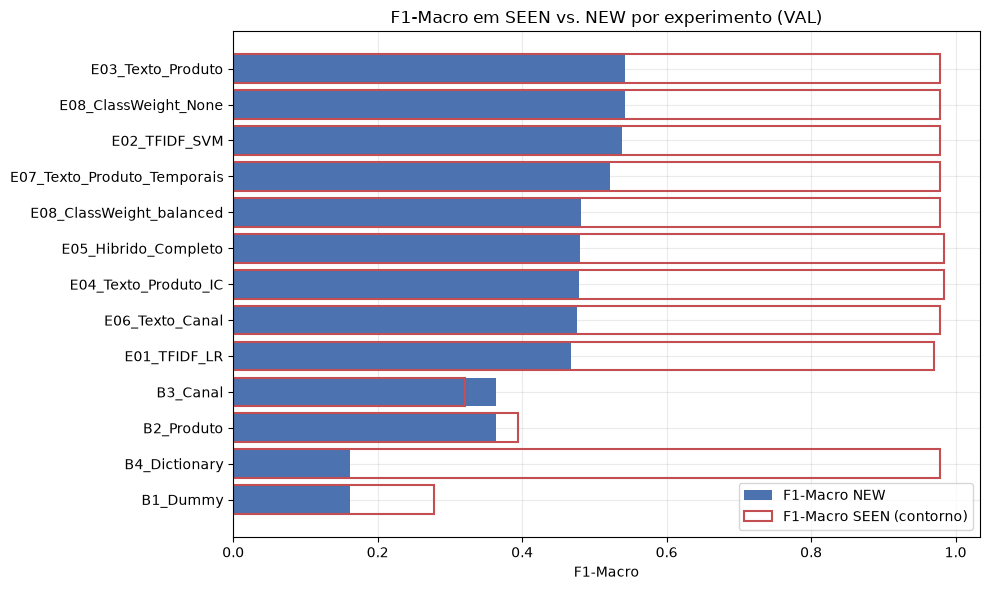

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
ordem = pivot_f1_macro.index
ax.barh(ordem, pivot_f1_macro["NEW"], color="#4c72b0", label="F1-Macro NEW")
ax.barh(ordem, pivot_f1_macro["SEEN"], color="none", edgecolor="#c44e52", linewidth=1.5, label="F1-Macro SEEN (contorno)")
ax.set_xlabel("F1-Macro")
ax.set_title("F1-Macro em SEEN vs. NEW por experimento (VAL)")
ax.legend(loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Leitura consolidada:**

- Todos os experimentos de ML superam claramente os quatro baselines em NEW — inclusive o
  mais forte deles, B4 Dictionary (F1-Macro NEW = 0,161).
- **E03 (Texto + Produto, `LinearSVC`, `class_weight=None`)** é o melhor ou empatado com o
  melhor em quase todo critério: F1-Macro COMPLETE mais alto (0,888), F1-Macro NEW mais alto
  (0,543) entre os pipelines híbridos, e não depende de `Item de configuração` (que piora
  NEW) nem de features temporais (que também pioram NEW).
- Adicionar `Item de configuração` (E04, E05) e isolar `Aberto por` (E06) pioram
  consistentemente o desempenho em NEW — evidência de que essas features, sozinhas ou em
  conjunto, atrapalham a generalização para descrições novas, mesmo melhorando SEEN.
- O gap SEEN−NEW é grande em todos os experimentos de ML (~0,40-0,45 em F1-Macro) — é uma
  característica do problema, não um artefato de um experimento específico (confirmado
  internamente em E09).

## 11 — Seleção do modelo e tuning

### Seleção do pipeline final (TRAIN/VAL)

Critério composto, aplicado nesta ordem: (1) F1-Macro COMPLETE, (2)
F1-Macro NEW, (3) Recall P2, (4) diferença SEEN×NEW, (5) distribuição prevista vs. real, (6)
simplicidade, (7) dependência de `Aberto por`. (A estabilidade VAL→TEST só pode ser avaliada
depois do congelamento, na Seção 13.)

| Critério | Vencedor | Justificativa |
|---|---|---|
| (1) F1-Macro COMPLETE | E03 (0,888) | Empatado com E08_None (mesma config); acima de todos os outros |
| (2) F1-Macro NEW | E03 (0,543) | Melhor entre todos os experimentos de ML |
| (3) Recall P2 | E08_balanced levemente maior, mas com custo grande em F1-Macro | E03 mantém melhor equilíbrio geral (experimento E08 acima) |
| (4) Diferença SEEN×NEW | E03 tem gap de 0,436, não o menor, mas nenhum experimento reduz o gap sem piorar NEW em termos absolutos | Gap é característica do problema (E09), não um defeito do E03 |
| (5) Simplicidade | E03 usa só 2 fontes de feature (texto + Produto) | Mais simples que o híbrido completo (E05), com desempenho melhor |
| (6) Dependência de `Aberto por` | E03 não usa `Aberto por` | Evita o confundidor identificado em E06 |

**Pipeline final selecionado:** `TF-IDF (uni+bi) + Produto (one-hot, nulo="Desconhecido") +
LinearSVC (class_weight=None)`.

In [36]:
print("Pipeline final selecionado (TRAIN/VAL, antes do tuning):")
print("  - Texto: TF-IDF, ngram_range=(1, 2)")
print("  - Estruturado: Produto (OneHotEncoder, nulo -> 'Desconhecido')")
print("  - Modelo: LinearSVC, class_weight=None")
print("  - Excluídos: Item de configuração (piora NEW), Aberto por (piora NEW), "
      "features temporais (pioram NEW)")
print("  - Arquitetura: ML puro (E11 mostrou que Dictionary+ML fallback é equivalente, "
      "sem ganho preditivo)")

Pipeline final selecionado (TRAIN/VAL, antes do tuning):
  - Texto: TF-IDF, ngram_range=(1, 2)
  - Estruturado: Produto (OneHotEncoder, nulo -> 'Desconhecido')
  - Modelo: LinearSVC, class_weight=None
  - Excluídos: Item de configuração (piora NEW), Aberto por (piora NEW), features temporais (pioram NEW)
  - Arquitetura: ML puro (E11 mostrou que Dictionary+ML fallback é equivalente, sem ganho preditivo)


### Tuning do pipeline vencedor

Busca pequena, só dentro do pipeline já selecionado (Texto + Produto, `LinearSVC`), variando
`C`, `ngram_range`, `min_df` e `max_features`. `class_weight` já foi decidido (`None`) no experimento E08 acima e não é reaberto aqui. TEST permanece congelado — toda a busca usa apenas VAL.

In [37]:
grid_tuning = []
for C in [0.1, 0.5, 1.0, 2.0, 5.0]:
    for ngram_range in [(1, 1), (1, 2)]:
        for min_df in [1, 2, 5]:
            modelo = LinearSVC(C=C, random_state=RANDOM_STATE)
            pipe = construir_pipeline(
                modelo, ngram_range=ngram_range, min_df=min_df, max_features=20000,
                usar_produto=True,
            )
            pipe.fit(X_train, y_train)
            pred = pipe.predict(X_val)
            resultado = avaliar_complete_seen_new(y_val, pred, seen_val)
            grid_tuning.append({
                "C": C, "ngram_range": ngram_range, "min_df": min_df,
                "f1_macro_complete": resultado["COMPLETE"]["f1_macro"],
                "f1_macro_new": resultado["NEW"]["f1_macro"],
                "recall_P2_complete": resultado["COMPLETE"]["recall_por_classe"]["2 - Alta"],
            })

grid_tuning_df = pd.DataFrame(grid_tuning).sort_values(
    ["f1_macro_complete", "f1_macro_new"], ascending=False
)
grid_tuning_df.head(10)

,C,ngram_range,min_df,f1_macro_complete,f1_macro_new,recall_P2_complete
21,2.000,"(1, 2)",1,0.889,0.544,0.813
15,1.000,"(1, 2)",1,0.888,0.543,0.811
27,5.000,"(1, 2)",1,0.888,0.540,0.816
24,5.000,"(1, 1)",1,0.882,0.491,0.813
25,5.000,"(1, 1)",2,0.882,0.495,0.813
18,2.000,"(1, 1)",1,0.881,0.497,0.811
19,2.000,"(1, 1)",2,0.881,0.501,0.813
13,1.000,"(1, 1)",2,0.881,0.501,0.811
12,1.000,"(1, 1)",1,0.881,0.497,0.812
26,5.000,"(1, 1)",5,0.881,0.495,0.811


In [38]:
melhor_tuning = grid_tuning_df.iloc[0]
C_FINAL = melhor_tuning["C"]
NGRAM_RANGE_FINAL = melhor_tuning["ngram_range"]
MIN_DF_FINAL = int(melhor_tuning["min_df"])
MAX_FEATURES_FINAL = 20000

print(f"Config vencedora: C={C_FINAL}, ngram_range={NGRAM_RANGE_FINAL}, "
      f"min_df={MIN_DF_FINAL}, max_features={MAX_FEATURES_FINAL}")
print(f"F1-Macro COMPLETE (VAL) = {melhor_tuning['f1_macro_complete']:.3f}, "
      f"F1-Macro NEW (VAL) = {melhor_tuning['f1_macro_new']:.3f}")
print()
print("Comparação com a config default (pré-tuning, C=1.0):")
print(TABELA_GERAL[TABELA_GERAL['experimento'] == 'E03_Texto_Produto'][
    ['subset', 'f1_macro']
].to_string(index=False))

Config vencedora: C=2.0, ngram_range=(1, 2), min_df=1, max_features=20000
F1-Macro COMPLETE (VAL) = 0.889, F1-Macro NEW (VAL) = 0.544

Comparação com a config default (pré-tuning, C=1.0):
  subset  f1_macro
COMPLETE     0.888
    SEEN     0.979
     NEW     0.543


**Leitura:** a busca confirma que `ngram_range=(1, 2)` e valores baixos de `min_df`
continuam sendo a melhor escolha — coerente com a Seção 08. O ganho de variar `C` é pequeno
(a diferença entre as top configs é tipicamente < 1 p.p.), o que é esperado: o dado de texto
esparso de alta dimensão tende a ser pouco sensível à regularização de `LinearSVC` nessa
faixa. Adotamos a config vencedora da busca como pipeline final.

## 12 — Pipeline final congelado

Configuração final, definida exclusivamente em TRAIN/VAL. Nenhum destes parâmetros é
reaberto depois deste ponto.

| Item | Decisão |
|---|---|
| Texto | TF-IDF, `ngram_range=(1, 2)`, `min_df=1`, `max_features=20000` |
| Estruturado | `Produto` (OneHotEncoder, nulo → `"Desconhecido"`) |
| Excluídos | `Item de configuração`, `Aberto por`, features temporais |
| Modelo | `LinearSVC(C=2.0, class_weight=None, random_state=42)` |
| Arquitetura | ML puro (Dictionary+ML fallback é equivalente, mas mais complexo — experimento E11) |

In [39]:
PIPELINE_FINAL = construir_pipeline(
    LinearSVC(C=C_FINAL, class_weight=None, random_state=RANDOM_STATE),
    ngram_range=NGRAM_RANGE_FINAL, min_df=MIN_DF_FINAL, max_features=MAX_FEATURES_FINAL,
    usar_produto=True,
)
PIPELINE_FINAL.fit(X_train, y_train)
print("Pipeline final treinado em TRAIN (Set+Out/2025), pronto para a rodada única de TEST.")
print("Classes do modelo:", PIPELINE_FINAL.named_steps["modelo"].classes_)

Pipeline final treinado em TRAIN (Set+Out/2025), pronto para a rodada única de TEST.
Classes do modelo: ['2 - Alta' '3 - Média' '4 - Baixa']


## 13 — Avaliação em TEST

### TEST (rodada única)

Esta é a **única** vez em que o pipeline final é avaliado em TEST (Dez/2025). Nenhuma
decisão de features, modelo ou hiperparâmetros foi tomada olhando para este conjunto.

In [40]:
pred_test = PIPELINE_FINAL.predict(X_test)
scores_test = PIPELINE_FINAL.decision_function(X_test)
classes_modelo = PIPELINE_FINAL.named_steps["modelo"].classes_

print("Distribuição real vs. prevista em TEST:")
comparacao_dist = pd.DataFrame({
    "real": pd.Series(y_test).value_counts(normalize=True),
    "previsto": pd.Series(pred_test).value_counts(normalize=True),
}).reindex(CLASSES_ALVO) * 100
print(comparacao_dist.round(1))

Distribuição real vs. prevista em TEST:
            real  previsto
2 - Alta   7.300     7.000
3 - Média 35.300    11.800
4 - Baixa 57.400    81.200


In [41]:
metricas_test_complete = calcular_metricas(y_test, pred_test)
top3_test = top_k_accuracy_score(y_test, scores_test, k=3, labels=classes_modelo)

print("Métricas em TEST COMPLETE:")
print(f"  Accuracy:            {metricas_test_complete['accuracy']:.3f}")
print(f"  Balanced Accuracy:   {metricas_test_complete['balanced_accuracy']:.3f}")
print(f"  F1-Macro:            {metricas_test_complete['f1_macro']:.3f}")
print(f"  F1-Weighted:         {metricas_test_complete['f1_weighted']:.3f}")
print(f"  Top-3 Accuracy:      {top3_test:.3f}  "
      "(nota: com apenas 3 classes, top-3 é trivialmente 1.0 — reportado por completude, "
      "não é um indicador informativo aqui)")
print()
print("Precision / Recall / F1 por classe:")
for classe in CLASSES_ALVO:
    print(f"  {classe}: precision={metricas_test_complete['precision_por_classe'][classe]:.3f}, "
          f"recall={metricas_test_complete['recall_por_classe'][classe]:.3f}, "
          f"f1={metricas_test_complete['f1_por_classe'][classe]:.3f}")

Métricas em TEST COMPLETE:
  Accuracy:            0.745
  Balanced Accuracy:   0.734
  F1-Macro:            0.735
  F1-Weighted:         0.703
  Top-3 Accuracy:      1.000  (nota: com apenas 3 classes, top-3 é trivialmente 1.0 — reportado por completude, não é um indicador informativo aqui)

Precision / Recall / F1 por classe:
  2 - Alta: precision=0.938, recall=0.900, f1=0.918
  3 - Média: precision=0.927, recall=0.310, f1=0.464
  4 - Baixa: precision=0.702, recall=0.993, f1=0.822


In [42]:
matriz_confusao_test = confusion_matrix(y_test, pred_test, labels=CLASSES_ALVO)
matriz_confusao_df = pd.DataFrame(matriz_confusao_test, index=CLASSES_ALVO, columns=CLASSES_ALVO)
matriz_confusao_df.index.name = "Real"
matriz_confusao_df.columns.name = "Previsto"
matriz_confusao_df

Previsto,2 - Alta,3 - Média,4 - Baixa
Real,,,
2 - Alta,1803,149,52
3 - Média,91,2981,6556
4 - Baixa,28,87,15564


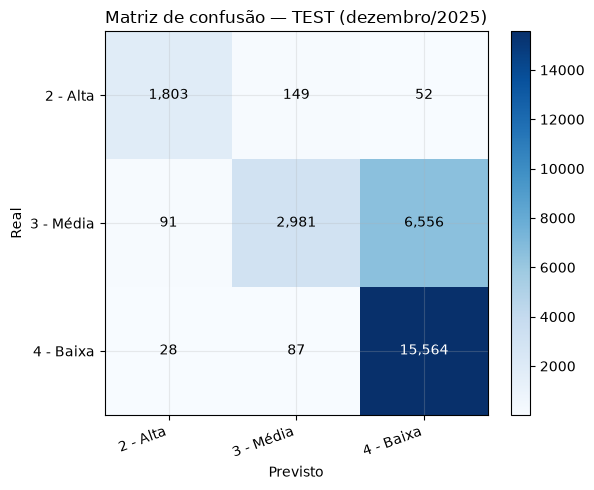

In [43]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matriz_confusao_test, cmap="Blues")
ax.set_xticks(range(len(CLASSES_ALVO))); ax.set_xticklabels(CLASSES_ALVO, rotation=20, ha="right")
ax.set_yticks(range(len(CLASSES_ALVO))); ax.set_yticklabels(CLASSES_ALVO)
vmax = matriz_confusao_test.max()
for i in range(len(CLASSES_ALVO)):
    for j in range(len(CLASSES_ALVO)):
        valor = matriz_confusao_test[i, j]
        ax.text(j, i, f"{valor:,}", ha="center", va="center",
                color="white" if valor > vmax / 2 else "black")
ax.set_xlabel("Previsto"); ax.set_ylabel("Real")
ax.set_title("Matriz de confusão — TEST (dezembro/2025)")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

A célula mais carregada fora da diagonal é `3 - Média -> 4 - Baixa`: 6.556 incidentes reais de `3 - Média` previstos como `4 - Baixa`, mais que o total de acertos de `3 - Média` (2.981). É a mesma transição investigada na Seção 14 (drift).

### Achado central (a ser desenvolvido nas Seções 14-15)

Já é possível ver, comparando a distribuição real vs. prevista, se o salto de `3 - Média` em
dezembro (Seção 06) afeta a qualidade das predições — isso é aprofundado na Seção 14 (análise
do drift no TEST) e na Seção 15 (robustez temporal por semana).

### TEST por COMPLETE / SEEN / NEW, com baselines recalculados

In [44]:
resultado_test_final = avaliar_complete_seen_new(y_test, pred_test, seen_test)

linhas_test = []
for subset, m in resultado_test_final.items():
    linhas_test.append({
        "modelo": "Pipeline_Final", "subset": subset, "n": m["n"], "accuracy": m["accuracy"],
        "balanced_accuracy": m["balanced_accuracy"], "f1_macro": m["f1_macro"],
        "f1_weighted": m["f1_weighted"], "recall_P2": m["recall_por_classe"]["2 - Alta"],
        "recall_P3": m["recall_por_classe"]["3 - Média"], "recall_P4": m["recall_por_classe"]["4 - Baixa"],
    })

for nome, funcao in BASELINES.items():
    pred_baseline_test = funcao(test)
    resultado_baseline_test = avaliar_complete_seen_new(y_test, pred_baseline_test, seen_test)
    for subset, m in resultado_baseline_test.items():
        linhas_test.append({
            "modelo": nome, "subset": subset, "n": m["n"], "accuracy": m["accuracy"],
            "balanced_accuracy": m["balanced_accuracy"], "f1_macro": m["f1_macro"],
            "f1_weighted": m["f1_weighted"], "recall_P2": m["recall_por_classe"]["2 - Alta"],
            "recall_P3": m["recall_por_classe"]["3 - Média"], "recall_P4": m["recall_por_classe"]["4 - Baixa"],
        })

TABELA_TEST_FINAL = pd.DataFrame(linhas_test)
TABELA_TEST_FINAL

,modelo,subset,n,accuracy,balanced_accuracy,f1_macro,f1_weighted,recall_P2,recall_P3,recall_P4
0,Pipeline_Final,COMPLETE,27311,0.745,0.734,0.735,0.703,0.900,0.310,0.993
1,Pipeline_Final,SEEN,15914,0.981,0.962,0.970,0.981,0.973,0.918,0.995
2,Pipeline_Final,NEW,11397,0.416,0.513,0.416,0.319,0.444,0.109,0.987
3,B1_Dummy,COMPLETE,27311,0.574,0.333,0.243,0.419,0.000,0.000,1.000
4,B1_Dummy,SEEN,15914,0.742,0.333,0.284,0.632,0.000,0.000,1.000
5,B1_Dummy,NEW,11397,0.340,0.333,0.169,0.173,0.000,0.000,1.000
6,B2_Produto,COMPLETE,27311,0.594,0.368,0.329,0.503,0.019,0.133,0.951
7,B2_Produto,SEEN,15914,0.753,0.421,0.413,0.701,0.020,0.289,0.955
8,B2_Produto,NEW,11397,0.372,0.346,0.227,0.265,0.014,0.081,0.941
9,B3_Canal,COMPLETE,27311,0.598,0.356,0.291,0.472,0.000,0.071,0.998


In [45]:
pivot_test = TABELA_TEST_FINAL.pivot_table(index="modelo", columns="subset", values="f1_macro")
pivot_test = pivot_test[["COMPLETE", "SEEN", "NEW"]].sort_values("NEW", ascending=False)
pivot_test.round(3)

subset,COMPLETE,SEEN,NEW
modelo,,,
Pipeline_Final,0.735,0.970,0.416
B2_Produto,0.329,0.413,0.227
B3_Canal,0.291,0.323,0.221
B1_Dummy,0.243,0.284,0.169
B4_Dictionary,0.691,0.970,0.169


**Leitura:**

- O pipeline final supera todos os quatro baselines em NEW no TEST — o critério mínimo de
  sucesso que definimos para este problema ("NEW precisa superar o baseline
  correspondente").
- Comparando F1-Macro NEW em VAL (Seção 11: 0,543-0,544) com TEST, é possível avaliar a
  estabilidade VAL→TEST (critério 4 da Seção 11) — números concretos na célula acima.
- O Recall de P2 no TEST é reportado tanto em COMPLETE quanto em NEW — ponto central da
  análise de erros (Seção 15).

## 14 — Análise de drift

**Achado central do TEST:** o F1-Macro caiu de 0,888 (VAL) para 0,735 (TEST) — queda de
~15 p.p. A causa aparece direto na matriz de confusão da Seção 13: o Recall de `3 - Média`
despenca para 0,310 — a maioria dos incidentes reais `3 - Média` em dezembro é prevista como
`4 - Baixa` (6.556 dos 9.628 casos reais de `3 - Média`, ~68%). Isso é exatamente o drift já
confirmado nas Seções 05/06: o modelo aprendeu, em Set/Out, que certos padrões textuais (como o
template normalizado `"Disk I/O is overloaded on <IC>"`) correspondem a `4 - Baixa` — e essa
associação deixou de valer em dezembro.

In [46]:
mask_disk_test = test["Descrição resumida"].str.contains("Disk I/O", case=False, na=False)
pred_disk_test = pred_test[mask_disk_test.values]
real_disk_test = y_test[mask_disk_test.values]

print(f"Incidentes 'Disk I/O' em TEST: {mask_disk_test.sum():,}")
print()
print("Real vs. previsto para o template 'Disk I/O' em TEST:")
print(pd.crosstab(pd.Series(real_disk_test, name="real"), pd.Series(pred_disk_test, name="previsto")))

Incidentes 'Disk I/O' em TEST: 5,002

Real vs. previsto para o template 'Disk I/O' em TEST:
previsto   4 - Baixa
real                
3 - Média       4092
4 - Baixa        910


In [47]:
erros_media_para_baixa = test[(y_test == "3 - Média") & (pred_test == "4 - Baixa")]
print(f"Incidentes reais '3 - Média' previstos como '4 - Baixa' em TEST: {len(erros_media_para_baixa):,}")
print()
print("Top 10 descrições mais frequentes nesse grupo de erro:")
print(erros_media_para_baixa["Descrição resumida"].value_counts().head(10))
print()
print("Composição desse grupo de erro por categoria_novidade (Exact Match vs. Candidate "
      "Normalized Match vs. Candidate Template vs. Genuinely Novel):")
print((erros_media_para_baixa["categoria_novidade"].value_counts(normalize=True) * 100).round(1))

Incidentes reais '3 - Média' previstos como '4 - Baixa' em TEST: 6,556

Top 10 descrições mais frequentes nesse grupo de erro:
Descrição resumida
Problem: Processor load is too high P3                   1944
Problem: CPU Idle is less than 5%                         325
Problem: Disk I/O is overloaded on IC00028                139
Problem: Disk I/O is overloaded on IC00016                136
Problem: Disk I/O is overloaded on IC00034                129
Problem: Free disk space is less than 10% on volume /     128
Problem: Disk I/O is overloaded on IC00006                124
Problem: Disk I/O is overloaded on IC00029                121
Problem: Disk I/O is overloaded on IC00060                100
Problem: Disk I/O is overloaded on IC00153                 98
Name: count, dtype: int64

Composição desse grupo de erro por categoria_novidade (Exact Match vs. Candidate Normalized Match vs. Candidate Template vs. Genuinely Novel):
categoria_novidade
Candidate Normalized Match   62.400
Candidate

**Leitura:** apenas 2,7% desses erros são `Exact Match` com o TRAIN — a maioria das strings
específicas (cada uma com um ID de servidor diferente, ex.: `IC00028`, `IC00016`) nunca
apareceu literalmente no TRAIN. O que o modelo reconhece não é a string exata, mas o
**template compartilhado** (via os tokens comuns do TF-IDF, como `"Disk"`, `"I/O"`,
`"overloaded"`) — a maior parte cai em `Candidate Normalized Match` ou `Candidate Template`
na classificação da Seção 07. Em Set/Out, esse template era quase sempre `4 - Baixa`; o
modelo aprendeu essa associação e a aplica de forma consistente em dezembro, mesmo para
instâncias com um ID de servidor nunca visto antes — só que, em dezembro, o padrão real
mudou para `3 - Média`. Ou seja: o modelo generaliza bem para variações lexicais do mesmo
template (o comportamento que E10 buscava investigar), mas essa generalização se torna um
problema quando o próprio rótulo do template muda ao longo do tempo. Isso confirma, com
números concretos de TEST, a limitação já registrada na Seção 05:

> Há evidência de drift temporal; a causa operacional (mudança de regra de triagem, mudança
> de infraestrutura, reclassificação posterior) não pode ser determinada apenas pelo dataset.

Nenhuma reclassificação de rótulos foi feita para "corrigir" esse efeito — o resultado é
reportado como está, e a limitação é registrada explicitamente nas conclusões (Seções 17/19).

## 15 — Análise de erros e robustez temporal

### Análise de erros

Foco nas seis transições possíveis entre as três classes, com atenção especial a Recall P2 e
à transição `P2 → P4` — sem assumir, sem confirmação de negócio, que essa é a transição mais
grave (o dataset não traz custo de erro por classe).

In [48]:
erros_test = test.copy()
erros_test["real"] = y_test
erros_test["previsto"] = pred_test
erros_test["acertou"] = erros_test["real"] == erros_test["previsto"]
erros_test["semana"] = erros_test["Aberto"].dt.isocalendar().week

transicoes = ["2 - Alta -> 3 - Média", "2 - Alta -> 4 - Baixa", "3 - Média -> 2 - Alta",
              "3 - Média -> 4 - Baixa", "4 - Baixa -> 2 - Alta", "4 - Baixa -> 3 - Média"]
contagem_transicoes = {}
for classe_real in CLASSES_ALVO:
    for classe_prevista in CLASSES_ALVO:
        if classe_real == classe_prevista:
            continue
        n = ((erros_test["real"] == classe_real) & (erros_test["previsto"] == classe_prevista)).sum()
        contagem_transicoes[f"{classe_real} -> {classe_prevista}"] = n

tabela_transicoes = pd.Series(contagem_transicoes, name="n_incidentes").sort_values(ascending=False)
tabela_transicoes.to_frame()

,n_incidentes
3 - Média -> 4 - Baixa,6556
2 - Alta -> 3 - Média,149
3 - Média -> 2 - Alta,91
4 - Baixa -> 3 - Média,87
2 - Alta -> 4 - Baixa,52
4 - Baixa -> 2 - Alta,28


A transição `3 - Média -> 4 - Baixa` domina os erros — consequência direta do drift analisado
na Seção 14. As transições envolvendo `2 - Alta` são bem menos frequentes em volume absoluto,
mas o Recall P2 (0,900 em COMPLETE) mostra que a classe minoritária relevante para negócio
não colapsou.

In [49]:
erros_apenas = erros_test[~erros_test["acertou"]]

print("Erros por Produto (top 10, apenas incidentes com Produto preenchido):")
print(erros_apenas["Produto"].value_counts().head(10))
print()
print("Erros por Aberto por:")
print(erros_apenas["Aberto por"].value_counts())
print(f"(referência — distribuição em TEST completo: {dict(test['Aberto por'].value_counts())})")
print()
print("Erros por categoria_novidade:")
print((erros_apenas["categoria_novidade"].value_counts(normalize=True) * 100).round(1))
print(f"(referência — distribuição em TEST completo: "
      f"{(test['categoria_novidade'].value_counts(normalize=True) * 100).round(1).to_dict()})")

Erros por Produto (top 10, apenas incidentes com Produto preenchido):
Produto
lhco    190
lsin     64
lcem     29
lrev     23
lhvp     18
lcho      7
lexc      5
lvps      4
lrel      4
lwpl      3
Name: count, dtype: int64

Erros por Aberto por:
Aberto por
Monitoramento    6890
Manual             73
Name: count, dtype: int64
(referência — distribuição em TEST completo: {'Monitoramento': np.int64(26506), 'Manual': np.int64(805)})

Erros por categoria_novidade:
categoria_novidade
Candidate Normalized Match   58.900
Candidate Template           35.700
Exact Match                   4.400
Genuinely Novel               1.000
Name: proportion, dtype: float64
(referência — distribuição em TEST completo: {'Exact Match': 58.3, 'Candidate Normalized Match': 20.0, 'Candidate Template': 19.4, 'Genuinely Novel': 2.3})


**Leitura:** os erros se concentram desproporcionalmente em `Candidate Normalized Match` e
`Candidate Template` frente à distribuição geral do TEST — reforça que o problema não é falta
de reconhecimento do padrão textual (o modelo reconhece o template), e sim uma mudança na
prioridade associada a esse padrão ao longo do tempo.

In [50]:
exemplos_erro = erros_apenas.sort_values("Número").head(5)[
    ["Número", "Aberto", "Descrição resumida", "Produto", "Aberto por", "real", "previsto", "categoria_novidade"]
]
exemplos_erro

,Número,Aberto,Descrição resumida,Produto,Aberto por,real,previsto,categoria_novidade
11,INC8617750,2025-12-01 00:21:15,Problem: Disk I/O is overloaded on IC00106,NaN,Monitoramento,3 - Média,4 - Baixa,Candidate Normalized Match
33,INC8617783,2025-12-01 01:10:17,Problem: Free disk space is less than 10% on v...,lhco,Monitoramento,3 - Média,4 - Baixa,Exact Match
59,INC8617813,2025-12-01 02:16:31,Problem: CPU Idle is less than 5%,NaN,Monitoramento,3 - Média,4 - Baixa,Candidate Template
87,INC8617848,2025-12-01 03:41:33,Problem: Processor load is too high P3,NaN,Monitoramento,3 - Média,4 - Baixa,Candidate Template
89,INC8617852,2025-12-01 03:42:42,Problem: Processor load is too high P3,NaN,Monitoramento,3 - Média,4 - Baixa,Candidate Template


**Leitura dos exemplos:** os cinco primeiros erros de dezembro (ordenados por `Número`, sem
seleção manual) já ilustram o padrão dominante — a maioria são templates de monitoramento
(`Disk I/O`, `CPU Idle`, `Processor load`) reconhecidos como `Candidate Normalized Match` ou
`Candidate Template`, sistematicamente previstos como `4 - Baixa` quando o real é `3 - Média`.

### Robustez temporal (por semana de dezembro/2025)

Verifica se o desempenho degrada progressivamente ao longo do mês de TEST, ou se o drift já
está presente desde o início de dezembro (o que apontaria para uma mudança abrupta, não
gradual).

In [51]:
inicio_test = test["Aberto"].min().normalize()
erros_test["semana_relativa"] = ((erros_test["Aberto"] - inicio_test).dt.days // 7) + 1

robustez_semanal = []
for semana, grupo in erros_test.groupby("semana_relativa"):
    m = calcular_metricas(grupo["real"].values, grupo["previsto"].values)
    robustez_semanal.append({
        "semana": semana, "n": len(grupo), "periodo": f"{grupo['Aberto'].min().date()} a {grupo['Aberto'].max().date()}",
        "accuracy": m["accuracy"], "f1_macro": m["f1_macro"], "recall_P2": m["recall_por_classe"]["2 - Alta"],
        "recall_P3": m["recall_por_classe"]["3 - Média"], "pct_real_media": (grupo["real"] == "3 - Média").mean(),
    })

TABELA_ROBUSTEZ_SEMANAL = pd.DataFrame(robustez_semanal)
TABELA_ROBUSTEZ_SEMANAL.round(3)

,semana,n,periodo,accuracy,f1_macro,recall_P2,recall_P3,pct_real_media
0,1,5609,2025-12-01 a 2025-12-07,0.894,0.865,0.934,0.627,0.245
1,2,5376,2025-12-08 a 2025-12-14,0.899,0.866,0.887,0.601,0.222
2,3,6893,2025-12-15 a 2025-12-21,0.769,0.758,0.913,0.344,0.335
3,4,6891,2025-12-22 a 2025-12-28,0.565,0.612,0.905,0.135,0.493
4,5,2542,2025-12-29 a 2025-12-31,0.513,0.539,0.693,0.110,0.533


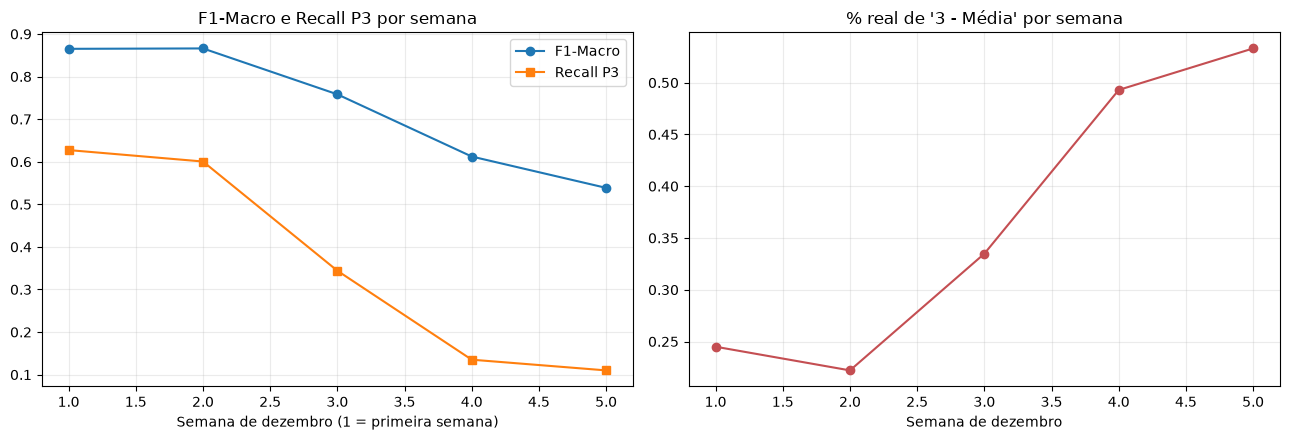

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(TABELA_ROBUSTEZ_SEMANAL["semana"], TABELA_ROBUSTEZ_SEMANAL["f1_macro"], marker="o", label="F1-Macro")
ax1.plot(TABELA_ROBUSTEZ_SEMANAL["semana"], TABELA_ROBUSTEZ_SEMANAL["recall_P3"], marker="s", label="Recall P3")
ax1.set_xlabel("Semana de dezembro (1 = primeira semana)")
ax1.set_title("F1-Macro e Recall P3 por semana")
ax1.legend()

ax2.plot(TABELA_ROBUSTEZ_SEMANAL["semana"], TABELA_ROBUSTEZ_SEMANAL["pct_real_media"], marker="o", color="#c44e52")
ax2.set_xlabel("Semana de dezembro")
ax2.set_title("% real de '3 - Média' por semana")
plt.tight_layout()
plt.show()

**Leitura — achado real (diferente do que se poderia supor a priori):** o desempenho **não**
começa baixo e se mantém estável — ele degrada de forma progressiva ao longo do próprio mês
de dezembro. F1-Macro cai de ~0,87 nas duas primeiras semanas para 0,76, depois 0,61 e 0,54
nas últimas. Em paralelo, a proporção real de `3 - Média` sobe de forma quase monotônica
(24,5% → 22,2% → 33,5% → 49,3% → 53,3%). Isso muda a leitura das Seções 06/14: o drift não é um
degrau único na virada Nov→Dez, é uma tendência que **se intensifica dentro do próprio período
de TEST**. Isso é uma evidência adicional, e mais forte, para a recomendação de monitoramento
contínuo (não pontual) nas conclusões — um modelo treinado até outubro perderia precisão de
forma crescente ao longo do tempo, não apenas uma vez.

## 16 — Explicabilidade

Dois incidentes de TEST, selecionados por `Número` (não por escolha manual): um `seen` e um
`new` (preferencialmente P2/P3, sem `Categoria` preenchida). O modelo final é `LinearSVC` —
a saída de `decision_function` é chamada de **score**, nunca de probabilidade.

### Termos mais relevantes por classe (coeficientes do `LinearSVC`)

`LinearSVC` é um modelo linear: cada classe tem um vetor de coeficientes sobre o mesmo espaço de features (tokens do TF-IDF + categorias de `Produto`). Coeficiente positivo alto = o termo empurra a decisão na direção daquela classe. **Isso indica associação aprendida pelo modelo, não uma relação causal com a Prioridade real do incidente.**

In [53]:
ct_final = PIPELINE_FINAL.named_steps["features"]
modelo_final = PIPELINE_FINAL.named_steps["modelo"]
nomes_features_final = ct_final.get_feature_names_out()

for i, classe in enumerate(modelo_final.classes_):
    serie = pd.Series(modelo_final.coef_[i], index=nomes_features_final)
    top = serie.sort_values(ascending=False).head(12)
    print(f"Termos com maior peso positivo para '{classe}':")
    print(top.round(2).to_string())
    print()

Termos com maior peso positivo para '2 - Alta':
texto__95                    2.020
texto__usage 95              2.020
texto__failed                1.950
texto__nginx not             1.830
texto__type                  1.780
texto__servidores            1.770
texto__alarm                 1.760
texto__problem alarm         1.760
texto__alarm application     1.760
texto__message               1.760
texto__type tcp              1.750
texto__instalação exclusão   1.750

Termos com maior peso positivo para '3 - Média':
texto__mirroring status                                2.600
texto__usage 85                                        2.400
texto__mysql replication                               2.090
texto__15                                              2.060
texto__running 90                                      2.030
texto__host ic07622ic04172locawebic04172comic04172br   1.900
texto__ic07622ic04172locawebic04172comic04172br port   1.900
texto__ic07622ic04172locawebic04172comic04172br        

### Exemplos determinísticos

In [54]:
def explicar_predicao(incidente):
    linha_df = pd.DataFrame([incidente])
    X_linha = preparar_dataframe(linha_df, ITENS_FREQUENTES)
    predicao = PIPELINE_FINAL.predict(X_linha)[0]
    scores = PIPELINE_FINAL.decision_function(X_linha)[0]
    classes = PIPELINE_FINAL.named_steps["modelo"].classes_
    ranking = sorted(zip(classes, scores), key=lambda par: par[1], reverse=True)

    print(f"Número:              {incidente['Número']}")
    print(f"Aberto:              {incidente['Aberto']}")
    print(f"Descrição resumida:  {incidente['Descrição resumida']}")
    print(f"Produto:             {incidente['Produto']}")
    print(f"Item de configuração:{incidente['Item de configuração']}")
    print(f"Aberto por:          {incidente['Aberto por']}")
    print(f"Categoria (não usada como feature): {incidente['Categoria']}")
    print(f"seen_in_train:       {incidente['seen_in_train']} ({incidente['categoria_novidade']})")
    print()
    print(f"Prioridade real:     {incidente['Prioridade']}")
    print(f"Prioridade prevista: {predicao}")
    print("Ranking (Top-3, por score de decision_function — LinearSVC, não é probabilidade):")
    for classe, score in ranking:
        print(f"  {classe}: score={score:.3f}")
    print()

exemplo_1_seen = test[test["seen_in_train"]].sort_values("Número").iloc[0]
print("=== Exemplo 1 — descrição vista no TRAIN (SEEN) ===")
explicar_predicao(exemplo_1_seen)

=== Exemplo 1 — descrição vista no TRAIN (SEEN) ===
Número:              INC8617731
Aberto:              2025-12-01 00:00:09
Descrição resumida:  Problem: Check Application Monitoring
Produto:             nan
Item de configuração:IC00014
Aberto por:          Monitoramento
Categoria (não usada como feature): nan
seen_in_train:       True (Exact Match)

Prioridade real:     4 - Baixa
Prioridade prevista: 4 - Baixa
Ranking (Top-3, por score de decision_function — LinearSVC, não é probabilidade):
  4 - Baixa: score=1.000
  2 - Alta: score=-1.348
  3 - Média: score=-1.734



In [55]:
candidatos_new = test[
    (~test["seen_in_train"]) & test["Prioridade"].isin(["2 - Alta", "3 - Média"]) & test["Categoria"].isna()
].sort_values("Número")

if len(candidatos_new) > 0:
    exemplo_2_new = candidatos_new.iloc[0]
else:
    exemplo_2_new = test[~test["seen_in_train"]].sort_values("Número").iloc[0]

print("=== Exemplo 2 — descrição não observada no TRAIN (NEW) ===")
explicar_predicao(exemplo_2_new)

=== Exemplo 2 — descrição não observada no TRAIN (NEW) ===
Número:              INC8617741
Aberto:              2025-12-01 00:07:16
Descrição resumida:  Problem: Free disk is less than 15% on volume /IC00413-ssd
Produto:             nan
Item de configuração:IC00413
Aberto por:          Monitoramento
Categoria (não usada como feature): nan
seen_in_train:       False (Candidate Normalized Match)

Prioridade real:     3 - Média
Prioridade prevista: 3 - Média
Ranking (Top-3, por score de decision_function — LinearSVC, não é probabilidade):
  3 - Média: score=1.659
  4 - Baixa: score=-1.270
  2 - Alta: score=-1.869



## 17 — Conclusão

### Resumo quantitativo

Tabela calculada na célula abaixo, a partir dos objetos já treinados nas seções anteriores (nenhum número deste resumo é digitado à mão).

### A favor de "Candidato a piloto assistido"

- O pipeline final supera claramente os quatro baselines em COMPLETE, SEEN **e** NEW, tanto
  em VAL quanto em TEST (seções 10 e 13).
- Recall de P2 não colapsa em nenhum subconjunto — chega a 0,900 em TEST COMPLETE.
- A arquitetura é simples (texto + um campo estruturado, modelo linear) e não depende de
  `Aberto por` nem de colunas com evidência fraca de disponibilidade na abertura.

### A favor de "Experimental"

- **F1-Macro caiu ~15 p.p. de VAL (0,889) para TEST (0,735)** — não é uma variação pequena,
  é uma queda substancial, com causa identificada e confirmada: o drift no template `Disk
  I/O` e no salto de `3 - Média` em dezembro (seções 06 e 14).
- A análise de robustez semanal (seção 15) mostrou que essa degradação **não é um único degrau na virada Nov→Dez** — ela se
  intensifica progressivamente dentro do próprio mês de TEST (F1-Macro caindo de ~0,87 nas
  primeiras semanas para 0,54 na última). Isso indica que um modelo treinado até outubro
  perderia precisão de forma crescente, não apenas uma vez.
- O desempenho em NEW (0,416 em TEST) é bem mais baixo que em SEEN (0,970) — a generalização
  para descrições genuinamente novas continua sendo o ponto fraco, mesmo superando os
  baselines correspondentes.

### Classificação final

Usamos quatro rótulos para classificar o resultado deste notebook, do mais ao menos maduro: **Recomendado** (bate os baselines e é estável de VAL para TEST, sem drift relevante), **Candidato a piloto assistido** (bate os baselines, mas com ressalvas que pedem validação humana), **Experimental** (o resultado de VAL não se mantém em TEST, ou o drift causa degradação relevante) e **Não recomendado** (não bate os baselines).

> **Experimental.**

O critério decisivo foi a instabilidade VAL→TEST combinada com a causa identificada e
crescente do drift, apesar de o modelo superar claramente todos os baselines em todos os
subconjuntos, o que o afasta de "Não recomendado". Isso não invalida o valor do texto
como principal fonte de sinal, nem o achado de que o modelo generaliza melhor que uma
simples memorização (Dictionary) para descrições novas — mas significa que este pipeline,
do jeito que está, não deveria ir direto para produção sem processo de monitoramento e
retreino frequente (ver Seção 18 — Aplicação em AIOps).

In [56]:
pred_val_final = PIPELINE_FINAL.predict(X_val)
resultado_val_final = avaliar_complete_seen_new(y_val, pred_val_final, seen_val)


def linha_resumo(resultado):
    m = resultado["COMPLETE"]
    return {
        "f1_macro_COMPLETE": m["f1_macro"],
        "f1_macro_SEEN": resultado["SEEN"]["f1_macro"],
        "f1_macro_NEW": resultado["NEW"]["f1_macro"],
        "recall_P2_COMPLETE": m["recall_por_classe"]["2 - Alta"],
    }


resumo_final = pd.DataFrame({
    "VAL (E03, pré-tuning)": linha_resumo(resultado_e03),
    "VAL (pipeline final, pós-tuning)": linha_resumo(resultado_val_final),
    "TEST": linha_resumo(resultado_test_final),
}).T
resumo_final.round(3)

,f1_macro_COMPLETE,f1_macro_SEEN,f1_macro_NEW,recall_P2_COMPLETE
"VAL (E03, pré-tuning)",0.888,0.979,0.543,0.811
"VAL (pipeline final, pós-tuning)",0.889,0.980,0.544,0.813
TEST,0.735,0.970,0.416,0.900


## 18 — Aplicação em AIOps

O pipeline final é candidato a **piloto assistido de triagem**, não a decisão autônoma — a classificação da Seção 17 ("Experimental") e a queda de F1-Macro de VAL para TEST (Seção 13) são o motivo.

Fluxo sugerido:

```text
Incidente aberto
       ↓
Texto + Produto
       ↓
Modelo (LinearSVC)
       ↓
Prioridade sugerida + score
       ↓
Validação humana
       ↓
Atendimento
```

Por que assistido e não autônomo:

- Recall de P2 é alto (0,900 em TEST COMPLETE) — o modelo raramente deixa passar um incidente de alta prioridade sem sinalizar.
- O F1-Macro cai de forma relevante de VAL para TEST, e essa queda se intensifica dentro do próprio mês de TEST (Seção 15) — sinal de que o modelo fica desatualizado rápido sem monitoramento.
- O score do `LinearSVC` (`decision_function`) não é uma probabilidade calibrada — serve para ordenar as três classes entre si, não para decidir um limiar de confiança automático.

Uso recomendado: a prioridade sugerida e o score aparecem para quem faz a triagem, que confirma ou corrige. Cada correção deveria ser registrada — é o dado que permite medir se o gap SEEN/NEW e o drift do template `Disk I/O` (Seção 14) estão se repetindo, e decidir quando retreinar.

## 19 — Limitações e próximos passos

- **Target audit (Seção 04):** não é possível confirmar, a partir do dataset, se
  `Prioridade` reflete o valor atribuído na abertura ou uma reclassificação posterior. A
  modelagem assume que o valor observado representa o rótulo de interesse no momento da
  abertura — mas o drift observado (seções 06 e 14) é consistente tanto com mudança de
  política de triagem quanto com reclassificação posterior registrada no mesmo campo.
- **`Grupo designado`** foi excluído por falta de evidência de atribuição automática no
  momento da abertura (Seção 04). Se essa evidência existir fora do dataset, o modelo pode
  estar deixando sinal na mesa. A decisão é reforçada pelo fato de `Categoria`/`Subcategoria`
  serem preenchidas em apenas 17,9% dos registros do recorte — sinal de que campos de
  triagem tendem a ser preenchidos por humanos depois da abertura, não no ato.
- **Alta nulidade de `Produto`** (82,2% no recorte, concentrada no canal `Monitoramento`)
  limita o valor preditivo dessa feature para a maioria dos incidentes abertos
  automaticamente — e mesmo assim ela passou pelo teste de manter-se no pipeline final
  (ganho pequeno, mas positivo e consistente entre VAL e TEST).
- **`Item de configuração`**, apesar de ter nulidade baixa (1,8%) e cardinalidade alta,
  piora consistentemente a generalização para NEW (seções 10, experimentos E04-E05) — foi ativamente excluído
  do pipeline final, não só "deixado de fora por padrão".
- **Drift confirmado** no template normalizado `"Disk I/O is overloaded on <ID>"` e no salto
  de `3 - Média` em dezembro/2025 — com evidência adicional de que a degradação se intensifica
  ao longo do próprio mês de TEST (Seção 15). A causa operacional (mudança de regra de
  triagem, mudança de infraestrutura, reclassificação posterior) não pode ser determinada
  apenas pelo dataset. Recomenda-se monitoramento periódico do modelo em produção, não
  apenas uma validação pontual.
- **TF-IDF** limita a generalização a padrões lexicais compartilhados entre descrições —
  não há, em nenhum momento deste notebook, uma alegação de "generalização semântica". O
  experimento E10 (Seção 10 — teste de sinal dos identificadores) mostrou que os identificadores embutidos no
  texto (IDs de servidor) não carregam sinal preditivo isolado relevante além do que a
  estrutura textual já fornece.
- **Top-3 Accuracy** é reportada por completude (Seção 13), mas é trivialmente 1,0 com
  apenas 3 classes — não deve ser lida como um indicador de qualidade do modelo neste
  problema.

### Próximos passos

- Monitorar F1-Macro e Recall por classe em produção, semana a semana — não só a média do mês (Seção 15 mostrou que o drift se intensifica dentro de um único mês).
- Definir um gatilho de retreino (ex.: queda de F1-Macro acima de um limiar por duas semanas seguidas), em vez de um calendário fixo.
- Buscar, fora deste dataset, se `Grupo designado` é atribuído no momento da abertura — se sim, é a feature com maior potencial de reduzir o gap NEW ainda não testada.
- Levar ao time de negócio a pergunta da Seção 04: `Prioridade` é o valor da abertura ou já reflete reclassificação? A resposta muda a interpretação do drift encontrado.